# UQ analysis

Initial scaffolding for the evaluation runs:

- Load analysis config from `configs/uq_analysis.yaml`.
- Resolve eval run directories (explicit entries or via glob patterns).
- Build a unified long-format DataFrame with all available predictions/uncertainties.

Subsequent cells will add calibration (α, β, DIDO) and metrics step by step.

In [1]:
1+1

2

In [2]:
from pathlib import Path
import sys

import yaml
import pandas as pd

# Ensure the project root is on sys.path so that `scripts` is importable.
# In this project layout, notebooks live in `<root>/notebooks`
# and scripts/configs live in `<root>/scripts` and `<root>/configs`.
NOTEBOOK_DIR = Path.cwd().resolve()

if (NOTEBOOK_DIR / "scripts").is_dir() and (NOTEBOOK_DIR / "configs").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "scripts").is_dir() and (NOTEBOOK_DIR.parent / "configs").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.uq_eval import (
    AnalysisSettings,
    DEFAULT_RUN_PATTERNS,
    discover_runs,
    build_df_all,
    fit_alpha_gaussian,
)

CONFIG_PATH = PROJECT_ROOT / "configs" / "uq_analysis.yaml"
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Config not found: {CONFIG_PATH}")

with CONFIG_PATH.open("r") as f:
    cfg = yaml.safe_load(f)

settings_cfg = cfg.get("settings", {}) or {}
eval_root_cfg = settings_cfg.get("eval_root", "outputs/evals")
eval_root_path = (PROJECT_ROOT / eval_root_cfg).resolve()

settings = AnalysisSettings(
    eval_root=eval_root_path,
    dido_mode=str(settings_cfg.get("dido_mode", "logistic")),
    n_mc_samples=int(settings_cfg.get("n_mc_samples", 50)),
    n_ensemble_members=int(settings_cfg.get("n_ensemble_members", 10)),
    n_nf_samples=int(settings_cfg.get("n_nf_samples", 200)),
    large_error_quantile=float(settings_cfg.get("large_error_quantile", 0.9)),
)

runs_cfg = cfg.get("runs", {}) or {}
patterns_cfg = cfg.get("run_patterns", {}) or {}

# Start from uq_eval defaults and override with patterns from config when provided
run_patterns = dict(DEFAULT_RUN_PATTERNS)
for key, pattern in patterns_cfg.items():
    if pattern is not None:
        run_patterns[key] = pattern

runs: dict[str, Path] = {}
eval_root = settings.eval_root

for key, pattern in run_patterns.items():
    explicit = runs_cfg.get(key)
    if explicit:
        p = (eval_root / explicit).resolve()
        if p.exists():
            runs[key] = p
        else:
            print(f"[warn] explicit run path for {key} not found: {p}")
    else:
        tmp = discover_runs(eval_root=eval_root, run_patterns={key: pattern})
        if key in tmp:
            runs[key] = tmp[key]

if not runs:
    print("[warn] no runs resolved from config or patterns")
else:
    print("Resolved runs:")
    for k, p in sorted(runs.items()):
        print(f"  {k}: {p}")


Resolved runs:
  dido_gau_xs: /home/canelo/uncertainty_quantification/outputs/evals/dido_gau_xs_20251211-182343_292718
  dido_lpl_xs: /home/canelo/uncertainty_quantification/outputs/evals/dido_lpl_xs_20251211-182247_292714
  esm_gau_xs: /home/canelo/uncertainty_quantification/outputs/evals/esm_gauss_gau_xs_20251210-193833_291990
  esm_lpl_xs: /home/canelo/uncertainty_quantification/outputs/evals/esm_laplace_lpl_xs_20251210-191621_291944
  gau_xs: /home/canelo/uncertainty_quantification/outputs/evals/gau_xs_20251210-184548_291937
  lpl_xs: /home/canelo/uncertainty_quantification/outputs/evals/lpl_xs_20251210-184537_291936
  nf_gau_xs: /home/canelo/uncertainty_quantification/outputs/evals/nf_gau_xs_20251211-200553_292751
  nf_lpl_xs: /home/canelo/uncertainty_quantification/outputs/evals/nf_lpl_xs_20251211-194913_292744
  point_xs: /home/canelo/uncertainty_quantification/outputs/evals/point_xs_20251210-184525_291935


In [3]:
# Build the unified long-format DataFrame with all available runs.
# This will attach standard columns like head_type, aleatoric_source,
# epistemic_source, y_true, y_pred_mean, sigma_ale_orig_raw, sigma_epi_orig_raw.
#
# Subsequent cells will:
# - compute the large-error threshold from the point baseline,
# - fit alpha/beta calibration parameters on validation data,
# - and add calibrated sigmas and DIDO scores.

df_all = build_df_all(runs)
print(f"df_all shape: {df_all.shape}")

# Downcast common numeric columns and category-ize labels to save RAM early.
float_cols = [
    "y_true",
    "y_pred_mean",
    "sigma_ale_orig_raw",
    "sigma_epi_orig_raw",
    "sigma_total_orig_cal",
    "dido_strength_raw",
    "dido_vacuity_raw",
    "dido_entropy_raw",
    "log_prob_z_raw",
    "z_raw",
]
int_cols = ["id", "train_frac"]
cat_cols = ["head_type", "aleatoric_source", "epistemic_source", "split", "dataset"]

for col in float_cols:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce").astype("float32")
for col in int_cols:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce").astype("Int32")
for col in cat_cols:
    if col in df_all.columns:
        df_all[col] = df_all[col].astype("category")

df_all.head()


df_all shape: (1125605, 79)


,id,split,head_type,y_true,y_pred_mean,aleatoric_source,epistemic_source,dataset,train_frac,sigma_ale_orig_raw,...,y_pred_member_1,y_pred_member_2,y_true_orig,y_pred_base_orig,sigma_base_orig,z_raw,log_prob_z_raw,dido_strength_raw,dido_vacuity_raw,dido_entropy_raw
0,153397,train,point,9000.000977,10736.145508,none,none,id,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,152766,train,point,25998.994141,37248.238281,none,none,id,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,151238,train,point,42589.992188,48044.484375,none,none,id,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,64684,train,point,28994.990234,24595.283203,none,none,id,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,277489,train,point,6995.001953,7995.286133,none,none,id,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Ingest OOD evals (base heads, NF, DIDO) from outputs/evals and append to df_all.
import re
from pathlib import Path

eval_root = settings.eval_root  # absolute path to outputs/evals
frames_ood = []

NUM_COLS = [
    "y_true",
    "y_pred_mean",
    "y_pred_mc_mean",
    "y_pred_det",
    "sigma_ale_orig_raw",
    "sigma_epi_orig_raw",
    "sigma_ale_raw",
    "sigma_epi_raw",
    "sigma_total_orig_cal",
    "dido_strength_raw",
    "dido_vacuity_raw",
    "dido_entropy_raw",
    "z_raw",
    "log_prob_z_raw",
]

def normalize_preds(df: pd.DataFrame) -> pd.DataFrame:
    # Fill y_pred_mean from available columns
    if "y_pred_mean" not in df or df["y_pred_mean"].isna().all():
        if "y_pred_mc_mean" in df:
            df["y_pred_mean"] = df["y_pred_mc_mean"]
        elif "y_pred_det" in df:
            df["y_pred_mean"] = df["y_pred_det"]
    # Map sigma columns if needed
    if "sigma_ale_orig_raw" not in df and "sigma_ale_raw" in df:
        df["sigma_ale_orig_raw"] = df["sigma_ale_raw"]
    if "sigma_epi_orig_raw" not in df and "sigma_epi_raw" in df:
        df["sigma_epi_orig_raw"] = df["sigma_epi_raw"]
    return df

def downcast_frame(df: pd.DataFrame, head_type: str, ale_src: str, epi_src: str, label: str):
    df = normalize_preds(df)
    df["head_type"] = head_type
    df["aleatoric_source"] = ale_src
    df["epistemic_source"] = epi_src
    df["dataset"] = label
    df["split"] = "test"
    for col in NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")
    if "id" in df.columns:
        df["id"] = pd.to_numeric(df["id"], errors="coerce").astype("Int32")
    for col in ["head_type", "aleatoric_source", "epistemic_source", "dataset", "split"]:
        df[col] = df[col].astype("category")
    return df

# Base heads: ood_<label>_test.csv
for path in eval_root.rglob("ood_*_test.csv"):
    m = re.match(r"ood_(.+)_test\.csv", path.name)
    if not m:
        continue
    label = m.group(1)
    run_name = path.parent.name.lower()
    if run_name.startswith("point"):
        ht, ale, epi = "point", "none", "none"
    elif run_name.startswith("lpl"):
        ht, ale, epi = "laplace", "analytic", "none"
    elif run_name.startswith("gau"):
        ht, ale, epi = "gauss", "analytic", "none"
    elif run_name.startswith("esm_lpl"):
        ht, ale, epi = "laplace", "analytic", "ensemble"
    elif run_name.startswith("esm_gau"):
        ht, ale, epi = "gauss", "analytic", "ensemble"
    else:
        continue
    df = pd.read_csv(path)
    frames_ood.append(downcast_frame(df, ht, ale, epi, label))

# NF: flow_eval_ood_<label>.csv
for path in eval_root.rglob("flow_eval_ood_*.csv"):
    m = re.match(r"flow_eval_ood_(.+)\.csv", path.name)
    if not m:
        continue
    label = m.group(1)
    run_name = path.parent.name.lower()
    if "nf_lpl" in run_name or run_name.startswith("nf_lpl"):
        ht, ale = "laplace", "nf"
    elif "nf_gau" in run_name or run_name.startswith("nf_gau"):
        ht, ale = "gauss", "nf"
    else:
        continue
    df = pd.read_csv(path)
    frames_ood.append(downcast_frame(df, ht, ale, "none", label))

# DIDO: dido_ood_<label>.csv
for path in eval_root.rglob("dido_ood_*.csv"):
    m = re.match(r"dido_ood_(.+)\.csv", path.name)
    if not m:
        continue
    label = m.group(1)
    run_name = path.parent.name.lower()
    if "dido_lpl" in run_name or run_name.startswith("dido_lpl"):
        ht, ale = "laplace", "analytic"
    elif "dido_gau" in run_name or run_name.startswith("dido_gau"):
        ht, ale = "gauss", "analytic"
    else:
        continue
    df = pd.read_csv(path)
    frames_ood.append(downcast_frame(df, ht, ale, "dido", label))

if frames_ood:
    df_all = pd.concat([df_all] + frames_ood, ignore_index=True, copy=False)
    del frames_ood
    print("df_all dataset counts (including OOD):")
    print(df_all["dataset"].value_counts())
else:
    print("[warn] No OOD frames loaded after recursive scan")


df_all dataset counts (including OOD):
dataset
id               1125605
tail_odo          928088
tail_mpy          915670
tail_year_old     850920
tail_multi        830942
geo               357280
rare_manu         335566
Name: count, dtype: int64


In [5]:
from scripts.uq_eval import compute_large_error_threshold

# Use the point baseline on ID test to define the large-error threshold τ
df_point_test = df_all[
    (df_all["head_type"] == "point") & (df_all["split"] == "test")
]

if df_point_test.empty:
    print("[warn] no point baseline rows on test split; cannot compute τ")
    LARGE_ERROR_TAU = None
else:
    LARGE_ERROR_TAU = compute_large_error_threshold(
        df_point_test,
        quantile=settings.large_error_quantile,
    )
    print(f"Large-error threshold τ (quantile={settings.large_error_quantile}): {LARGE_ERROR_TAU:.2f}")

    # Optional quick sanity check: distribution of AE under the point baseline
    ae_point = (df_point_test["y_true"] - df_point_test["y_pred_mean"]).abs()
    print("\nPoint-baseline absolute error summary on test:")
    print(ae_point.describe())


Large-error threshold τ (quantile=0.9): 9681.65

Point-baseline absolute error summary on test:
count    634335.000000
mean       4095.494629
std        5511.481934
min           0.020508
25%        1013.804443
50%        2280.542969
75%        4846.960938
max      220956.531250
dtype: float64


In [6]:
# Prepare convenient slices for validation and test, and inspect method coverage.
# This will be used for calibration (val) and evaluation (test) in later cells.

df_val = df_all[df_all["split"] == "val"]
df_test = df_all[df_all["split"] == "test"]

print("Validation rows:", df_val.shape[0])
print("Test rows      :", df_test.shape[0])

print("\nValidation counts by (head_type, aleatoric_source):")
print(df_val.groupby(["head_type", "aleatoric_source"]).size())

print("\nTest counts by (head_type, aleatoric_source, epistemic_source):")
print(df_test.groupby(["head_type", "aleatoric_source", "epistemic_source"]).size())


Validation rows: 110943
Test rows      : 4567133

Validation counts by (head_type, aleatoric_source):
head_type  aleatoric_source
gauss      analytic            47547
laplace    analytic            47547
point      none                15849
dtype: int64

Test counts by (head_type, aleatoric_source, epistemic_source):
head_type  aleatoric_source  epistemic_source
gauss      analytic          dido                634335
                             ensemble             31697
                             mc                   31697
                             none                634335
           nf                none                634335
laplace    analytic          dido                634335
                             ensemble             31697
                             mc                   31697
                             none                634335
           nf                none                634335
point      none              none                634335
dtype: int64


In [7]:
# Fit aleatoric calibration α on the validation split.
# We restrict to rows with no epistemic component (epistemic_source == "none")
# and let fit_alpha_gaussian estimate one scalar α per (head_type, aleatoric_source)
# so that α * sigma_ale_orig_raw^2 best matches the observed squared errors.

from scripts.uq_eval import fit_alpha_gaussian

df_val_ale = df_val[df_val["epistemic_source"] == "none"].copy()
alpha = fit_alpha_gaussian(df_val_ale)

print("Aleatoric calibration α per (head_type, aleatoric_source):")
if not alpha:
    print("  [warn] no suitable rows found on val for alpha calibration")
else:
    for (head_type, ale_src), a in sorted(alpha.items()):
        print(f"  ({head_type}, {ale_src}): {a:.4f}")


Aleatoric calibration α per (head_type, aleatoric_source):
  (gauss, analytic): 1.0400
  (laplace, analytic): 0.3313


In [8]:
# Fit epistemic calibration β on the validation split.
# We restrict to rows where both aleatoric and epistemic stds are available,
# then let fit_beta_gaussian estimate one scalar β per
# (head_type, aleatoric_source, epistemic_source) so that
# sigma_total^2 = alpha * sigma_ale_raw^2 + β * sigma_epi_raw^2
# best matches the observed squared errors under a Gaussian NLL.

# Make sure fit_beta_gaussian was imported in the first cell:
# from scripts.uq_eval import (..., fit_beta_gaussian)

from scripts.uq_eval import fit_beta_gaussian  # remove this line if already imported above

df_val_epi = df_val[
    df_val["sigma_ale_orig_raw"].notna() & df_val["sigma_epi_orig_raw"].notna()
].copy()

beta = fit_beta_gaussian(df_val_epi, alpha)

print("Epistemic calibration β per (head_type, aleatoric_source, epistemic_source):")
if not beta:
    print("  [warn] no suitable rows found on val for beta calibration")
else:
    for (head_type, ale_src, epi_src), b in sorted(beta.items()):
        print(f"  ({head_type}, {ale_src}, {epi_src}): {b:.4f}")


Epistemic calibration β per (head_type, aleatoric_source, epistemic_source):
  (gauss, analytic, ensemble): 0.0010
  (gauss, analytic, mc): 0.0010
  (laplace, analytic, ensemble): 0.0631
  (laplace, analytic, mc): 0.0010


In [9]:
# Add calibrated aleatoric, epistemic, and total std columns to all rows.
# This uses the previously fitted alpha (per head/ale source) and beta
# (per head/ale/epi source) to compute:
#   sigma_ale_orig_cal, sigma_epi_orig_cal, sigma_total_orig_cal.

import numpy as np
import pandas as pd

alpha_df = pd.DataFrame(
    [(h, a, v) for (h, a), v in alpha.items()],
    columns=["head_type", "aleatoric_source", "alpha_val"],
)
beta_df = pd.DataFrame(
    [(h, a, e, v) for (h, a, e), v in beta.items()],
    columns=["head_type", "aleatoric_source", "epistemic_source", "beta_val"],
)

# Merge in calibration scalars without copying the whole frame twice
df_all_cal = df_all.merge(alpha_df, on=["head_type", "aleatoric_source"], how="left")
df_all_cal = df_all_cal.merge(
    beta_df, on=["head_type", "aleatoric_source", "epistemic_source"], how="left"
)
df_all_cal["alpha_val"].fillna(1.0, inplace=True)
df_all_cal["beta_val"].fillna(1.0, inplace=True)

s_ale = df_all_cal["sigma_ale_orig_raw"].to_numpy(dtype=float)
s_epi = df_all_cal["sigma_epi_orig_raw"].fillna(0.0).to_numpy(dtype=float)
a = df_all_cal["alpha_val"].to_numpy(dtype=float)
b = df_all_cal["beta_val"].to_numpy(dtype=float)

s_ale_cal = np.sqrt(np.maximum(a * (s_ale ** 2), 0.0))
s_epi_cal = np.sqrt(np.maximum(b * (s_epi ** 2), 0.0))
s_tot_cal = np.sqrt(np.maximum(s_ale_cal ** 2 + s_epi_cal ** 2, 0.0))

df_all_cal["sigma_ale_orig_cal"] = s_ale_cal.astype("float32")
df_all_cal["sigma_epi_orig_cal"] = s_epi_cal.astype("float32")
df_all_cal["sigma_total_orig_cal"] = s_tot_cal.astype("float32")

# Drop helper scalars and the original df_all reference to save memory
for col in ("alpha_val", "beta_val"):
    if col in df_all_cal.columns:
        df_all_cal.drop(columns=[col], inplace=True)

del df_all  # free the pre-calibration frame

print("Calibrated sigma columns added:")
for col in ["sigma_ale_orig_cal", "sigma_epi_orig_cal", "sigma_total_orig_cal"]:
    print(" ", col, "->", col in df_all_cal.columns)

# Quick peek

df_all_cal[
    [
        "head_type",
        "aleatoric_source",
        "epistemic_source",
        "sigma_ale_orig_raw",
        "sigma_ale_orig_cal",
        "sigma_epi_orig_raw",
        "sigma_epi_orig_cal",
        "sigma_total_orig_cal",
    ]
].head()

/tmp/ipykernel_3208665/2618219807.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_all_cal["alpha_val"].fillna(1.0, inplace=True)
/tmp/ipykernel_3208665/2618219807.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

Calibrated sigma columns added:
  sigma_ale_orig_cal -> True
  sigma_epi_orig_cal -> True
  sigma_total_orig_cal -> True


,head_type,aleatoric_source,epistemic_source,sigma_ale_orig_raw,sigma_ale_orig_cal,sigma_epi_orig_raw,sigma_epi_orig_cal,sigma_total_orig_cal
0,point,none,none,NaN,NaN,NaN,0.0,NaN
1,point,none,none,NaN,NaN,NaN,0.0,NaN
2,point,none,none,NaN,NaN,NaN,0.0,NaN
3,point,none,none,NaN,NaN,NaN,0.0,NaN
4,point,none,none,NaN,NaN,NaN,0.0,NaN


In [10]:
# Attach DIDO scores to base predictions and fit DIDO logistic calibration.
# This builds a DIDO+base subset (with y_true, y_pred_mean, sigma_total_orig_cal)
# and, if enabled, fits a simple logistic model that maps
# (vacuity, entropy, total sigma) -> P(large error).

from scripts.uq_eval import fit_dido_logistic  # ensure this was imported in the first cell

# All DIDO rows from the calibrated table
df_dido = df_all_cal[df_all_cal["epistemic_source"] == "dido"].copy()
print("DIDO rows (all splits):", df_dido.shape[0])

if df_dido.empty:
    print("[warn] no DIDO rows found; dido_params will be empty")
    dido_params = {}
else:
    # Base analytic predictions to join with (same head_type, id, split)
    base_cols = ["id", "split", "head_type", "y_true", "y_pred_mean", "sigma_total_orig_cal"]
    df_base = df_all_cal[
        (df_all_cal["aleatoric_source"] == "analytic")
        & (df_all_cal["epistemic_source"] == "none")
    ][base_cols].drop_duplicates()

    df_dido = df_dido.merge(
        df_base,
        on=["id", "split", "head_type"],
        how="inner",
        suffixes=("", "_base"),
    )

    # Copy base predictions into the columns expected by fit_dido_logistic
    for col in ["y_true", "y_pred_mean", "sigma_total_orig_cal"]:
        df_dido[col] = df_dido[f"{col}_base"]

    # Drop the temporary *_base columns to avoid confusion
    df_dido = df_dido.drop(columns=[c for c in df_dido.columns if c.endswith("_base")])

    print("DIDO rows after join with base preds:", df_dido.shape[0])

    # --- NEW: write the base predictions back into df_all_cal for DIDO rows ---
    # This is what allows later cells (large_error, AUROC/AUPRC) to see
    # non-NaN y_true / y_pred_mean for DIDO.
    key_cols = ["id", "split", "head_type", "epistemic_source"]
    upd_cols = ["y_true", "y_pred_mean", "sigma_total_orig_cal"]

    df_all_cal = df_all_cal.merge(
        df_dido[key_cols + upd_cols],
        on=key_cols,
        how="left",
        suffixes=("", "_from_dido"),
    )

    for col in upd_cols:
        src = f"{col}_from_dido"
        if src in df_all_cal.columns:
            # For DIDO rows, fill NaNs with the merged base values.
            df_all_cal[col] = df_all_cal[col].fillna(df_all_cal[src])
            df_all_cal.drop(columns=[src], inplace=True)

    # ------------------------------------------------------------------------- #

    # Fit logistic calibration only if configured and we have enough data
    if settings.dido_mode == "logistic" and LARGE_ERROR_TAU is not None and df_dido.shape[0] >= 1000:
        dido_params = fit_dido_logistic(df_dido, tau=LARGE_ERROR_TAU)
        if not dido_params:
            print("[warn] fit_dido_logistic returned no parameters; using raw scores instead")
        else:
            print("Fitted DIDO logistic parameters for keys:")
            for key in dido_params:
                print(" ", key)
    else:
        dido_params = {}
        print("[info] DIDO logistic calibration skipped; using raw vacuity/entropy as scores.")


DIDO rows (all splits): 1268670
DIDO rows after join with base preds: 2474048
Fitted DIDO logistic parameters for keys:
  ('gauss', 'analytic')
  ('laplace', 'analytic')


In [11]:
print("DIDO split counts before join:")
print(df_all_cal[df_all_cal["epistemic_source"] == "dido"]["split"].value_counts())

print("\nBase analytic split counts:")
print(df_base["split"].value_counts())

print("\nUnique head_type in DIDO vs base:")
print("DIDO:", df_all_cal[df_all_cal["epistemic_source"] == "dido"]["head_type"].unique())
print("Base:", df_base["head_type"].unique())


DIDO split counts before join:
split
test    11321878
Name: count, dtype: int64

Base analytic split counts:
split
test     755335
train    221882
val       31698
Name: count, dtype: int64

Unique head_type in DIDO vs base:
DIDO: ['laplace' 'gauss']
Base: ['laplace' 'gauss']


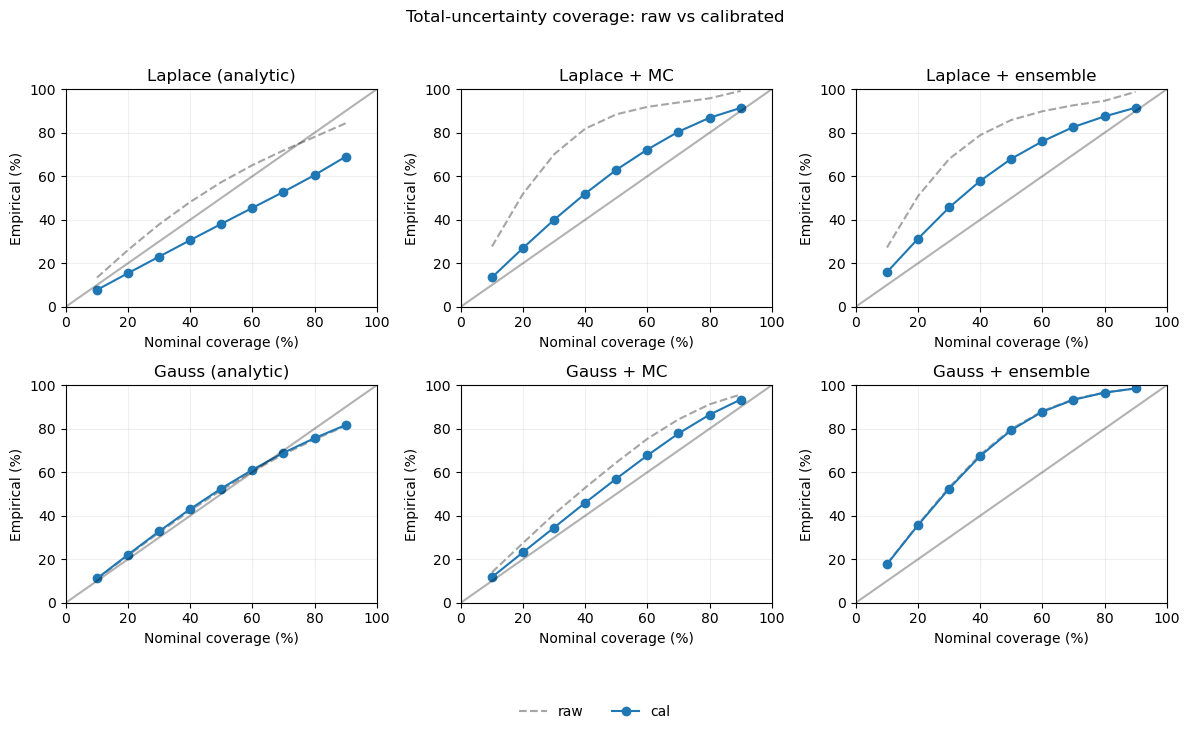

In [12]:
# Calibration visualization: coverage vs nominal for total uncertainty on ID test.
# Nominal levels from 10% to 90% (step 10%), one subplot per method,
# axes 0–100 on both axes, calibrated line in default blue, and the 45° line in black.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

cols_needed = [
    "split",
    "head_type",
    "aleatoric_source",
    "epistemic_source",
    "y_true",
    "y_pred_mean",
    "sigma_ale_orig_raw",
    "sigma_epi_orig_raw",
    "sigma_total_orig_cal",
]
df_test_cal = df_all_cal.loc[df_all_cal["split"] == "test", cols_needed].copy()

# Compute "raw" total sigma (no alpha/beta)
sigma_ale_sq_raw = df_test_cal["sigma_ale_orig_raw"].to_numpy(float) ** 2
sigma_epi_sq_raw = df_test_cal["sigma_epi_orig_raw"].fillna(0.0).to_numpy(float) ** 2
sigma_total_orig_raw = np.sqrt(np.maximum(sigma_ale_sq_raw + sigma_epi_sq_raw, 0.0))
df_test_cal["sigma_total_orig_raw"] = sigma_total_orig_raw

methods = [
    # ("point",   "none",     "none",      "Point"),
    ("laplace", "analytic", "none",      "Laplace (analytic)"),
    ("laplace", "analytic", "mc",        "Laplace + MC"),
    ("laplace", "analytic", "ensemble",  "Laplace + ensemble"),
    ("gauss",   "analytic", "none",      "Gauss (analytic)"),
    ("gauss",   "analytic", "mc",        "Gauss + MC"),
    ("gauss",   "analytic", "ensemble",  "Gauss + ensemble"),
]

nominal = np.arange(0.1, 1.0, 0.1)
z_for_p = {p: norm.ppf((1 + p) / 2) for p in nominal}

def coverage_for_method(df, head_type, ale_src, epi_src, sigma_col):
    sub = df[
        (df["head_type"] == head_type)
        & (df["aleatoric_source"] == ale_src)
        & (df["epistemic_source"] == epi_src)
    ]
    if sub.empty:
        return None
    y = sub["y_true"].to_numpy(float)
    mu = sub["y_pred_mean"].to_numpy(float)
    sigma = sub[sigma_col].to_numpy(float)
    err = np.abs(y - mu)
    return np.array([np.mean(err <= z_for_p[p] * sigma) for p in nominal])

n_methods = len(methods)
ncols = 3
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = axes.flatten()

for ax, (head_type, ale_src, epi_src, label) in zip(axes, methods):
    cov_raw = coverage_for_method(df_test_cal, head_type, ale_src, epi_src, "sigma_total_orig_raw")
    cov_cal = coverage_for_method(df_test_cal, head_type, ale_src, epi_src, "sigma_total_orig_cal")
    if cov_raw is None or cov_cal is None:
        ax.set_axis_off()
        continue
    ax.plot(nominal * 100, cov_raw * 100, "--", color="tab:gray", label="raw", alpha=0.7)
    ax.plot(nominal * 100, cov_cal * 100, "-o", color="tab:blue", label="cal")
    ax.plot([0, 100], [0, 100], "k-", alpha=0.3)  # Ideal 45° line
    ax.set_title(label)
    ax.set_xlabel("Nominal coverage (%)")
    ax.set_ylabel("Empirical (%)")
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

for ax in axes[len(methods):]:
    ax.set_axis_off()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.05),
    frameon=False,
)

fig.suptitle("Total-uncertainty coverage: raw vs calibrated", y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()



In [13]:
alpha


{('gauss', 'analytic'): 1.039994665677312,
 ('laplace', 'analytic'): 0.33128012982577687}

In [14]:
df_val[df_val["aleatoric_source"]=="analytic"]["head_type"].value_counts()


head_type
laplace    47547
gauss      47547
Name: count, dtype: int64

In [15]:
df_test = df_all_cal[df_all_cal["aleatoric_source"] == "analytic"]

print(df_test.groupby("head_type")[["sigma_ale_orig_raw", "sigma_total_orig_cal"]].describe())


          sigma_ale_orig_raw                                       \
                       count         mean           std       min   
head_type                                                           
gauss              1078099.0  8192.781250  16024.408203  1.803912   
laplace            1078099.0  8558.467773   6730.616699  0.000000   

                                                                 \
                   25%          50%           75%           max   
head_type                                                         
gauss      3154.840820  5829.835449  10791.941406  7.110140e+06   
laplace    2794.416748  6442.235840  13225.513672  6.444350e+04   

          sigma_total_orig_cal                                       \
                         count         mean           std       min   
head_type                                                             
gauss                6739020.0  5432.731934  21477.880859  1.839632   
laplace              6739056.0  27

In [16]:
df_test[df_test["sigma_total_orig_cal"]<=0].shape


(12692, 84)

In [17]:
# How big are the errors vs sigmas?
for ht in ["laplace","gauss"]:
    sub = df_all_cal[(df_all_cal["aleatoric_source"]=="analytic") &
                     (df_all_cal["head_type"]==ht) &
                     (df_all_cal["split"]=="test")]
    err = (sub["y_true"] - sub["y_pred_mean"]).abs()
    print("\n", ht)
    print("abs_error quantiles:", err.quantile([0.5,0.9,0.95,0.99]))
    print("sigma_total_cal quantiles:", sub["sigma_total_orig_cal"].quantile([0.5,0.9,0.95,0.99]))
    print("err/sigma quantiles:", (err / sub["sigma_total_orig_cal"]).quantile([0.5,0.9,0.95,0.99]))



 laplace
abs_error quantiles: 0.50     1787.165283
0.90     8879.638672
0.95    13654.297852
0.99    26989.699219
dtype: float64
sigma_total_cal quantiles: 0.50     1664.149902
0.90     5224.780273
0.95     7222.231934
0.99    10916.379883
Name: sigma_total_orig_cal, dtype: float64
err/sigma quantiles: 0.50      0.998242
0.90      4.112134
0.95      7.072474
0.99    291.524689
dtype: float64

 gauss
abs_error quantiles: 0.50     2169.265625
0.90    11350.084961
0.95    18187.394531
0.99    32903.664062
dtype: float64
sigma_total_cal quantiles: 0.50     3439.425781
0.90     9675.319336
0.95    13302.616211
0.99    23172.947266
Name: sigma_total_orig_cal, dtype: float64
err/sigma quantiles: 0.50    0.600950
0.90    2.382245
0.95    3.938052
0.99    9.159687
dtype: float64


In [18]:
# Save calibration/analysis record (alpha, beta, dido params, settings, runs).
# This creates a timestamped JSON under PROJECT_ROOT / "analysis"
# so we can always reproduce the calibration later.

from datetime import datetime
from scripts.uq_eval import save_analysis_record

analysis_dir = PROJECT_ROOT / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.utcnow().strftime("%Y%m%d-%H%M%S")
record_path = analysis_dir / f"uq_{timestamp}.json"

extra_meta = {
    "large_error_tau": LARGE_ERROR_TAU,
    "n_val_rows": int(df_val.shape[0]),
    "n_test_rows": int(df_test.shape[0]),
    "git_commit": None,  # fill this in manually if desired
}

runs_for_record = {k: str(p) for k, p in runs.items()}

eval_root_path = settings.eval_root
settings.eval_root = str(eval_root_path)

save_analysis_record(
    path=record_path,
    settings=settings,
    runs=runs_for_record,
    alpha=alpha,
    beta=beta,
    dido_params=dido_params if "dido_params" in locals() else {},
    extra_meta=extra_meta,
)

settings.eval_root = eval_root_path  # restore Path for later use

print(f"Saved calibration record to {record_path}")


Saved calibration record to /home/canelo/uncertainty_quantification/analysis/uq_20251213-231435.json


In [19]:
# Core ID-test metrics for analytic + MC/ensemble methods only.
# Computes MAE, RMSE, Gaussian NLL (using sigma_total_orig_cal),
# Normal CRPS, and summary stats for sigma_total_orig_cal.

import numpy as np
from scipy.stats import norm
from scripts.uq_eval import gaussian_nll  # ensure this was imported earlier

cols_needed = [
    "split",
    "head_type",
    "aleatoric_source",
    "epistemic_source",
    "y_true",
    "y_pred_mean",
    "sigma_total_orig_cal",
    "sigma_ale_orig_cal",
    "sigma_epi_orig_cal",
]
df_test_core = df_all_cal.loc[df_all_cal["split"] == "test", cols_needed].copy()

core_methods = [
    ("point",   "none",     "none",      "Point"),
    ("laplace", "analytic", "none",      "Laplace (analytic)"),
    ("laplace", "analytic", "mc",        "Laplace + MC"),
    ("laplace", "analytic", "ensemble",  "Laplace + ensemble"),
    ("gauss",   "analytic", "none",      "Gauss (analytic)"),
    ("gauss",   "analytic", "mc",        "Gauss + MC"),
    ("gauss",   "analytic", "ensemble",  "Gauss + ensemble"),
]

def normal_crps(y, mu, sigma):
    # Closed-form CRPS for a Normal predictive distribution.
    sigma = np.maximum(sigma, 1e-8)
    z = (y - mu) / sigma
    return np.mean(
        sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    )

rows = []
for head_type, ale_src, epi_src, label in core_methods:
    sub = df_test_core[
        (df_test_core["head_type"] == head_type)
        & (df_test_core["aleatoric_source"] == ale_src)
        & (df_test_core["epistemic_source"] == epi_src)
    ]
    if sub.empty:
        continue

    y = sub["y_true"].to_numpy(float)
    mu = sub["y_pred_mean"].to_numpy(float)
    sigma = sub["sigma_total_orig_cal"].to_numpy(float)

    mae = float(np.mean(np.abs(y - mu)))
    rmse = float(np.sqrt(np.mean((y - mu) ** 2)))

    mask = np.isfinite(sigma) & (sigma > 0)
    if np.any(mask):
        nll = gaussian_nll(mu[mask], sigma[mask], y[mask])
        crps = normal_crps(y[mask], mu[mask], sigma[mask])
        sigma_mean = float(np.mean(sigma[mask]))
        sigma_median = float(np.median(sigma[mask]))
    else:
        nll = np.nan
        crps = np.nan
        sigma_mean = np.nan
        sigma_median = np.nan

    rows.append(
        {
            "method": label,
            "head_type": head_type,
            "aleatoric_source": ale_src,
            "epistemic_source": epi_src,
            "n_test": int(sub.shape[0]),
            "MAE": mae,
            "RMSE": rmse,
            "NLL": nll,
            "CRPS": crps,
            "sigma_mean": sigma_mean,
            "sigma_median": sigma_median,
        }
    )

df_core_metrics = pd.DataFrame(rows).sort_values("method").reset_index(drop=True)
df_core_metrics


,method,head_type,aleatoric_source,epistemic_source,n_test,MAE,RMSE,NLL,CRPS,sigma_mean,sigma_median
0,Gauss (analytic),gauss,analytic,none,634335,5541.650216,34943.519733,226895.901495,4343.577743,5554.462521,3856.380127
1,Gauss + MC,gauss,analytic,mc,31697,7258.728995,10143.319556,13667.071691,5300.612914,11288.433517,9573.392578
2,Gauss + ensemble,gauss,analytic,ensemble,31697,5978.443931,8668.624627,13514.122433,4888.298831,14165.432315,12150.451172
3,Laplace (analytic),laplace,analytic,none,634335,4021.439033,7003.702699,533970.365503,3192.252666,2928.570338,1893.340576
4,Laplace + MC,laplace,analytic,mc,31697,5259.049679,7982.703616,98851.479598,3969.325700,7717.787375,7445.346680
5,Laplace + ensemble,laplace,analytic,ensemble,31697,5052.243902,7907.525977,78597.991522,3919.766623,7938.549390,7789.441895
6,Point,point,none,none,634335,4095.494650,6867.091991,NaN,NaN,NaN,NaN


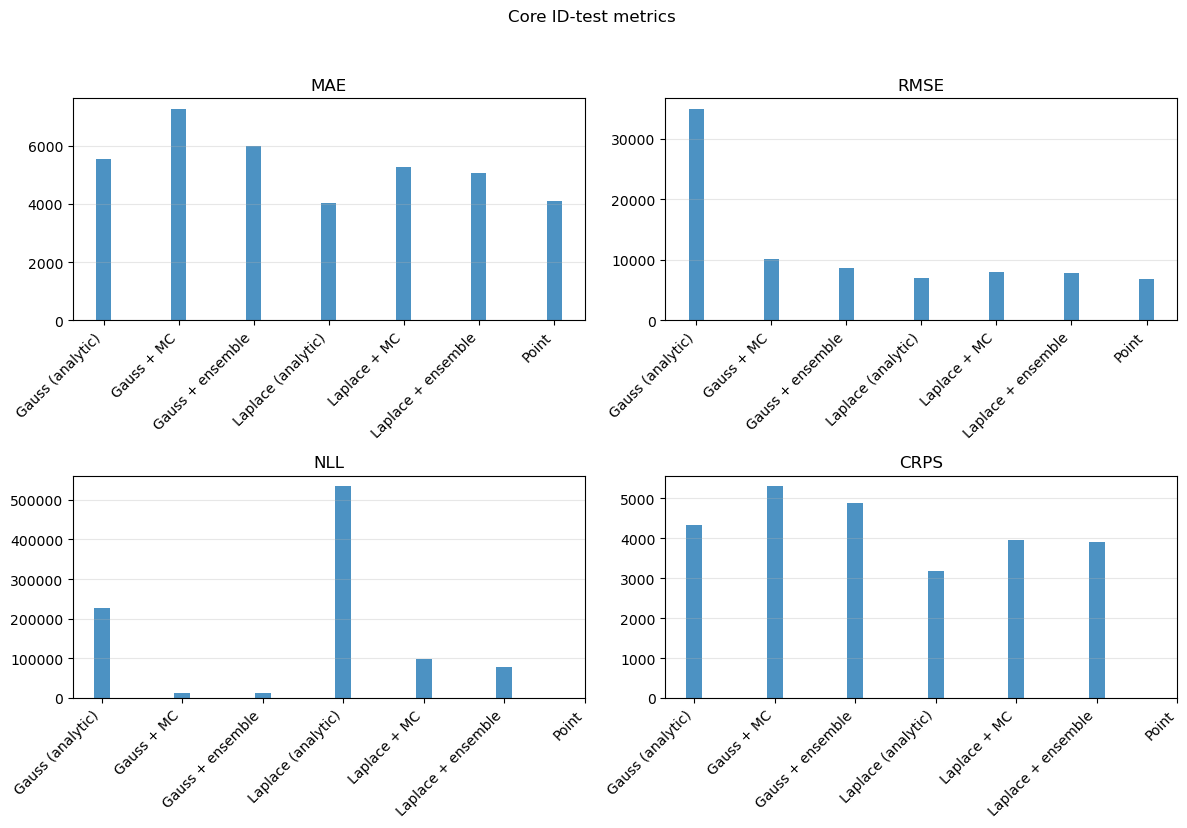

In [20]:
# Visualize core ID-test metrics (MAE, RMSE, NLL, CRPS) for the core methods.

import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ["MAE", "RMSE", "NLL", "CRPS"]
methods_order = df_core_metrics["method"].tolist()

x = np.arange(len(methods_order))
width = 0.2  # bar width

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    values = df_core_metrics.set_index("method")[metric]
    ax.bar(x, values[methods_order], width, color="tab:blue", alpha=0.8)
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(methods_order, rotation=45, ha="right")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Core ID-test metrics", y=1.03)
plt.tight_layout()
plt.show()


In [21]:
# Calibration diagnostics on ID-test for core methods:
# - Coverage at 10% to 90% (step 10) using sigma_total_orig_cal
# - Reliability bins (predicted variance vs empirical error^2)

import numpy as np
import pandas as pd
from scipy.stats import norm

# Work only on needed columns, no full copy of all columns
cols_needed = ["split", "head_type", "aleatoric_source", "epistemic_source",
               "y_true", "y_pred_mean", "sigma_total_orig_cal"]
df_test_core = df_all_cal.loc[df_all_cal["split"] == "test", cols_needed]

core_methods = [
    ("point",   "none",     "none",      "Point"),
    ("laplace", "analytic", "none",      "Laplace (analytic)"),
    ("laplace", "analytic", "mc",        "Laplace + MC"),
    ("laplace", "analytic", "ensemble",  "Laplace + ensemble"),
    ("gauss",   "analytic", "none",      "Gauss (analytic)"),
    ("gauss",   "analytic", "mc",        "Gauss + MC"),
    ("gauss",   "analytic", "ensemble",  "Gauss + ensemble"),
]

nominal = np.arange(0.1, 1.0, 0.1)
z_for_p = {p: norm.ppf((1 + p) / 2) for p in nominal}

coverage_rows = []
reliability_rows = []
n_bins = 10

for head_type, ale_src, epi_src, label in core_methods:
    sub = df_test_core[
        (df_test_core["head_type"] == head_type)
        & (df_test_core["aleatoric_source"] == ale_src)
        & (df_test_core["epistemic_source"] == epi_src)
    ]
    if sub.empty:
        continue

    y = sub["y_true"].to_numpy(float)
    mu = sub["y_pred_mean"].to_numpy(float)
    sigma = sub["sigma_total_orig_cal"].to_numpy(float)
    finite_sigma = np.isfinite(sigma) & (sigma > 0)
    sigma_f = sigma[finite_sigma]
    y_f = y[finite_sigma]
    mu_f = mu[finite_sigma]

    # Coverage
    err = np.abs(y - mu)
    cov_vals = [np.mean(err <= z_for_p[p] * sigma) if sigma.size else np.nan for p in nominal]
    coverage_rows.append(
        {
            "method": label,
            "head_type": head_type,
            "aleatoric_source": ale_src,
            "epistemic_source": epi_src,
            **{f"cov_{int(p*100)}": cov_vals[i] for i, p in enumerate(nominal)},
        }
    )

    # Reliability bins
    if sigma_f.size < n_bins:
        continue
    bin_edges = np.quantile(sigma_f, np.linspace(0, 1, n_bins + 1))
    # ensure edges are strictly increasing
    bin_edges = np.unique(bin_edges)
    if bin_edges.size < 2:
        continue
    bin_ids = np.digitize(sigma_f, bin_edges[1:-1], right=True)

    err2 = (y_f - mu_f) ** 2
    for b in range(bin_ids.min(), bin_ids.max() + 1):
        mask = bin_ids == b
        if not mask.any():
            continue
        sf = sigma_f[mask]
        ef = err2[mask]
        reliability_rows.append(
            {
                "method": label,
                "head_type": head_type,
                "aleatoric_source": ale_src,
                "epistemic_source": epi_src,
                "bin": int(b + 1),
                "bin_sigma_mean": float(sf.mean()),
                "bin_sigma_var": float((sf ** 2).mean()),
                "bin_err2_mean": float(ef.mean()),
                "count": int(mask.sum()),
            }
        )

df_core_coverage = pd.DataFrame(coverage_rows).sort_values("method").reset_index(drop=True)
df_core_reliability = pd.DataFrame(reliability_rows).sort_values(["method", "bin"]).reset_index(drop=True)

print("Coverage table:\n", df_core_coverage)
print("\nReliability bins (first few rows):\n", df_core_reliability.head())


Coverage table:
                method head_type aleatoric_source epistemic_source    cov_10  \
0    Gauss (analytic)     gauss         analytic             none  0.111230   
1          Gauss + MC     gauss         analytic               mc  0.117393   
2    Gauss + ensemble     gauss         analytic         ensemble  0.176736   
3  Laplace (analytic)   laplace         analytic             none  0.077137   
4        Laplace + MC   laplace         analytic               mc  0.134839   
5  Laplace + ensemble   laplace         analytic         ensemble  0.158911   
6               Point     point             none             none  0.000000   

     cov_20    cov_30    cov_40    cov_50    cov_60    cov_70    cov_80  \
0  0.220995  0.328279  0.430731  0.525169  0.611246  0.689213  0.756772   
1  0.231946  0.345648  0.459791  0.570275  0.677320  0.778212  0.864593   
2  0.356816  0.524687  0.674480  0.794050  0.878411  0.933338  0.966054   
3  0.154228  0.230148  0.305939  0.380792  0.45438

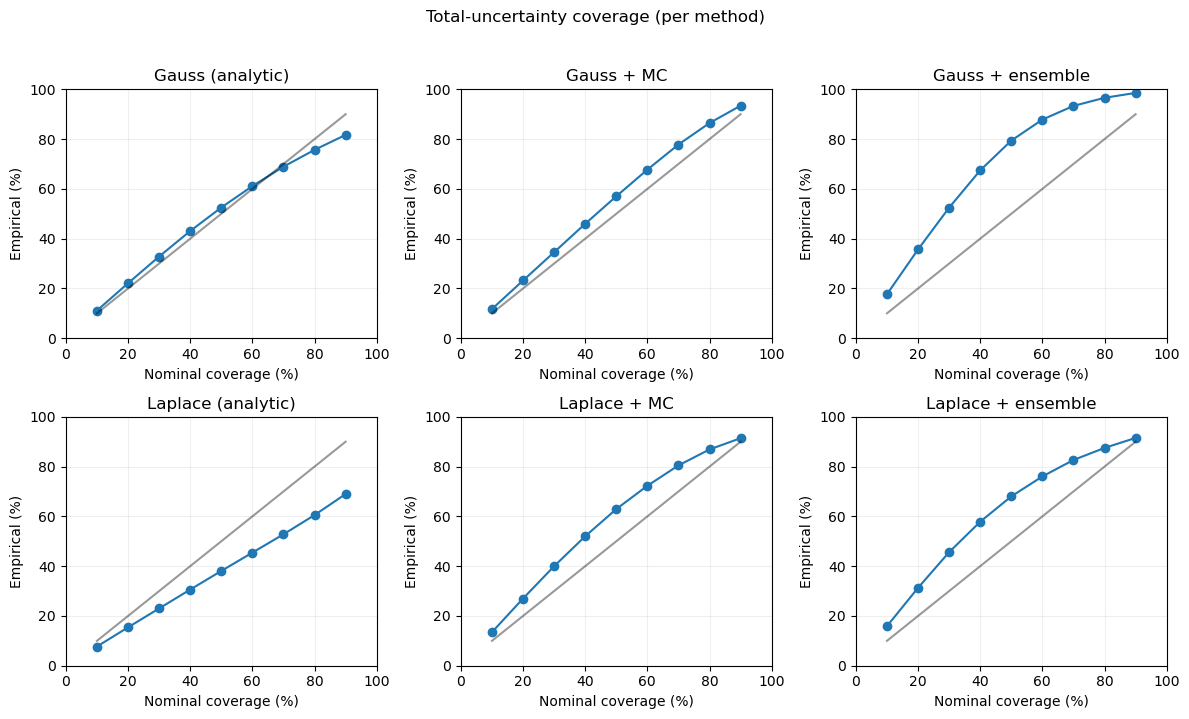

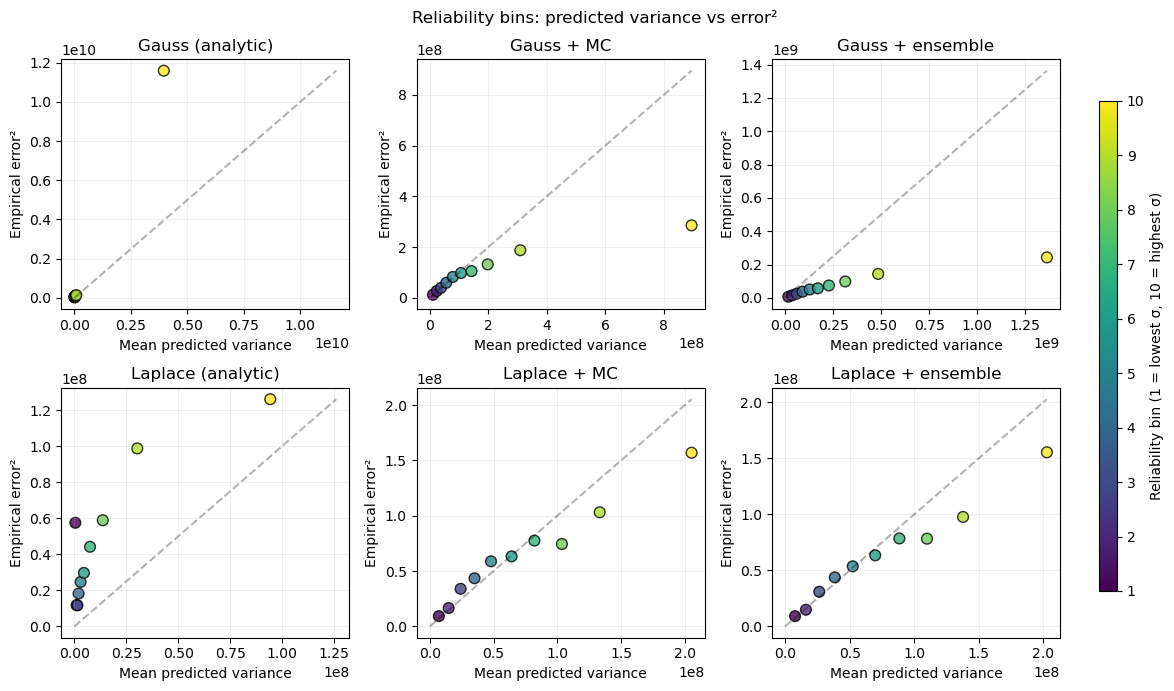

In [22]:
# Coverage + reliability diagnostics (per-method subplots, with a single colorbar for reliability bins).

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

methods_order = [m for m in df_core_coverage["method"] if "point" not in m.lower()]
nominal_levels = np.arange(10, 100, 10)

# --- Coverage subplot grid ---
n_methods = len(methods_order)
ncols = 3
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=False, sharey=False
)
axes = axes.flatten()

for ax, method in zip(axes, methods_order):
    row = df_core_coverage[df_core_coverage["method"] == method].iloc[0]
    coverages = [row[f"cov_{lvl}"] * 100 for lvl in nominal_levels]
    ax.plot(nominal_levels, coverages, "-o", color="tab:blue")
    ax.plot(nominal_levels, nominal_levels, "k-", alpha=0.4)
    ax.set_title(method)
    ax.set_xlabel("Nominal coverage (%)")
    ax.set_ylabel("Empirical (%)")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.2)

for ax in axes[len(methods_order):]:
    ax.set_axis_off()

fig.suptitle("Total-uncertainty coverage (per method)", y=1.02)
fig.tight_layout()
plt.show()

# --- Reliability scatter plots ---
rel_methods = methods_order  # already excludes point
n_methods_rel = len(rel_methods)
nrows_rel = int(np.ceil(n_methods_rel / ncols))
fig, axes = plt.subplots(
    nrows_rel, ncols, figsize=(4 * ncols, 3.5 * nrows_rel), sharex=False, sharey=False
)
axes = axes.flatten()
norm = Normalize(vmin=1, vmax=10)
cmap = plt.cm.viridis

scatters = []
for ax, method in zip(axes, rel_methods):
    sub = df_core_reliability[df_core_reliability["method"] == method]
    if sub.empty:
        ax.set_axis_off()
        continue
    sc = ax.scatter(
        sub["bin_sigma_var"],
        sub["bin_err2_mean"],
        c=sub["bin"],
        cmap=cmap,
        norm=norm,
        s=60,
        edgecolor="k",
        alpha=0.8,
    )
    scatters.append(sc)
    max_val = max(sub["bin_sigma_var"].max(), sub["bin_err2_mean"].max())
    ax.plot([0, max_val], [0, max_val], "k--", alpha=0.3)
    ax.set_title(method)
    ax.set_xlabel("Mean predicted variance")
    ax.set_ylabel("Empirical error²")
    ax.grid(True, alpha=0.2)

for ax in axes[len(rel_methods):]:
    ax.set_axis_off()

# First tighten layout, then add the manual colorbar to avoid warnings
fig.tight_layout(rect=[0, 0, 0.9, 0.96])

if scatters:
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap),
        cax=cbar_ax,
        label="Reliability bin (1 = lowest σ, 10 = highest σ)",
    )

fig.suptitle("Reliability bins: predicted variance vs error²", y=0.98)
plt.show()


In [23]:
# Rebuild the subset the histogram uses
df_nf = df_all_cal[
    (df_all_cal["split"] == "test")
    & (df_all_cal["head_type"].isin(["laplace", "gauss"]))
    & (df_all_cal["epistemic_source"] == "none")
    & (df_all_cal["aleatoric_source"].isin(["analytic", "nf"]))
].copy()
df_nf["method"] = (
    df_nf["head_type"].str.capitalize()
    + " "
    + df_nf["aleatoric_source"].map({"analytic": "(analytic)", "nf": "(NF)"})
)

# NaN counts overall and per method
print("Overall NaNs:\n", df_nf[["y_true","y_pred_mean","sigma_total_orig_cal"]].isna().sum())
print("\nNaNs per method:")
print(df_nf.groupby("method")[["y_true","y_pred_mean","sigma_total_orig_cal"]].apply(lambda x: x.isna().sum()))

# Rows causing problems
bad = df_nf[
    ~np.isfinite(df_nf["sigma_total_orig_cal"]) |
    ~np.isfinite(df_nf["y_true"]) |
    ~np.isfinite(df_nf["y_pred_mean"])
]
print("\nBad rows count:", bad.shape[0])
print(bad.head())


Overall NaNs:
 y_true                  1205276
y_pred_mean             1205276
sigma_total_orig_cal    1205276
dtype: int64

NaNs per method:
                    y_true  y_pred_mean  sigma_total_orig_cal
method                                                       
Gauss (NF)          602638       602638                602638
Gauss (analytic)         0            0                     0
Laplace (NF)        602638       602638                602638
Laplace (analytic)       0            0                     0

Bad rows count: 1205276
         id split head_type  y_true  y_pred_mean aleatoric_source  \
2933519   9  test     gauss     NaN          NaN               nf   
2933520  11  test     gauss     NaN          NaN               nf   
2933521  17  test     gauss     NaN          NaN               nf   
2933522  18  test     gauss     NaN          NaN               nf   
2933523  64  test     gauss     NaN          NaN               nf   

        epistemic_source   dataset  train_frac

In [24]:
import pandas as pd
from pathlib import Path
sample = next((settings.eval_root).rglob("ood_*_test.csv"))
df_sample = pd.read_csv(sample)
df_sample.columns
print(df_sample.head())


   id split head_type  mc_flag  n_mc        y_true    y_pred_det  \
0  15  test     gauss        0     0   6800.002441  10541.322266   
1  84  test     gauss        0     0  41590.003906  39918.328125   
2  85  test     gauss        0     0  30989.984375  29843.923828   
3  87  test     gauss        0     0  31990.001953  13267.484375   
4  88  test     gauss        0     0  29589.988281  28178.318359   

   y_pred_mc_mean  sigma_ale_raw  sigma_epi_raw  
0    10541.322266    7158.615723            NaN  
1    39918.328125    8609.868164            NaN  
2    29843.923828   10552.328125            NaN  
3    13267.484375   19734.433594            NaN  
4    28178.318359   12109.485352            NaN  


In [25]:
bad = df_all_cal[
    (df_all_cal["split"]=="test") &
    (df_all_cal["aleatoric_source"]=="analytic") &
    (df_all_cal["epistemic_source"]=="none") &
    (df_all_cal["y_pred_mean"].isna())
]
bad[["dataset","head_type"]].value_counts()
bad[["y_pred_mc_mean","y_pred_det","sigma_ale_orig_raw"]].notna().sum()


y_pred_mc_mean        0
y_pred_det            0
sigma_ale_orig_raw    0
dtype: int64

In [26]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# Slice only needed cols
df_nf = df_all_cal.loc[
    (df_all_cal["split"] == "test")
    & (df_all_cal["head_type"].isin(["laplace", "gauss"]))
    & (df_all_cal["epistemic_source"] == "none")
    & (df_all_cal["aleatoric_source"].isin(["analytic", "nf"])),
    ["head_type", "aleatoric_source", "y_true", "y_pred_mean", "sigma_total_orig_cal"],
].copy()

# If y_pred_mean is missing (e.g., OOD ingest), try to fill from available columns
if "y_pred_mc_mean" in df_all_cal.columns:
    df_nf["y_pred_mean"] = df_nf["y_pred_mean"].fillna(
        df_all_cal.loc[df_nf.index, "y_pred_mc_mean"]
    )
if "y_pred_det" in df_all_cal.columns:
    df_nf["y_pred_mean"] = df_nf["y_pred_mean"].fillna(
        df_all_cal.loc[df_nf.index, "y_pred_det"]
    )

# Drop any remaining non-finite rows to avoid plot crashes
df_nf = df_nf.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["y_true", "y_pred_mean", "sigma_total_orig_cal"]
)

# Add method label
df_nf["method"] = (
    df_nf["head_type"].str.capitalize()
    + " "
    + df_nf["aleatoric_source"].map({"analytic": "(analytic)", "nf": "(NF)"})
)

methods_nf = sorted(df_nf["method"].unique())
nominal = np.arange(0.1, 1.0, 0.1)
z_lookup = {p: norm.ppf((1 + p) / 2) for p in nominal}

print("df_nf shape:", df_nf.shape)
print("Methods:", methods_nf)


df_nf shape: (1332064, 6)
Methods: ['Gauss (NF)', 'Gauss (analytic)', 'Laplace (NF)', 'Laplace (analytic)']


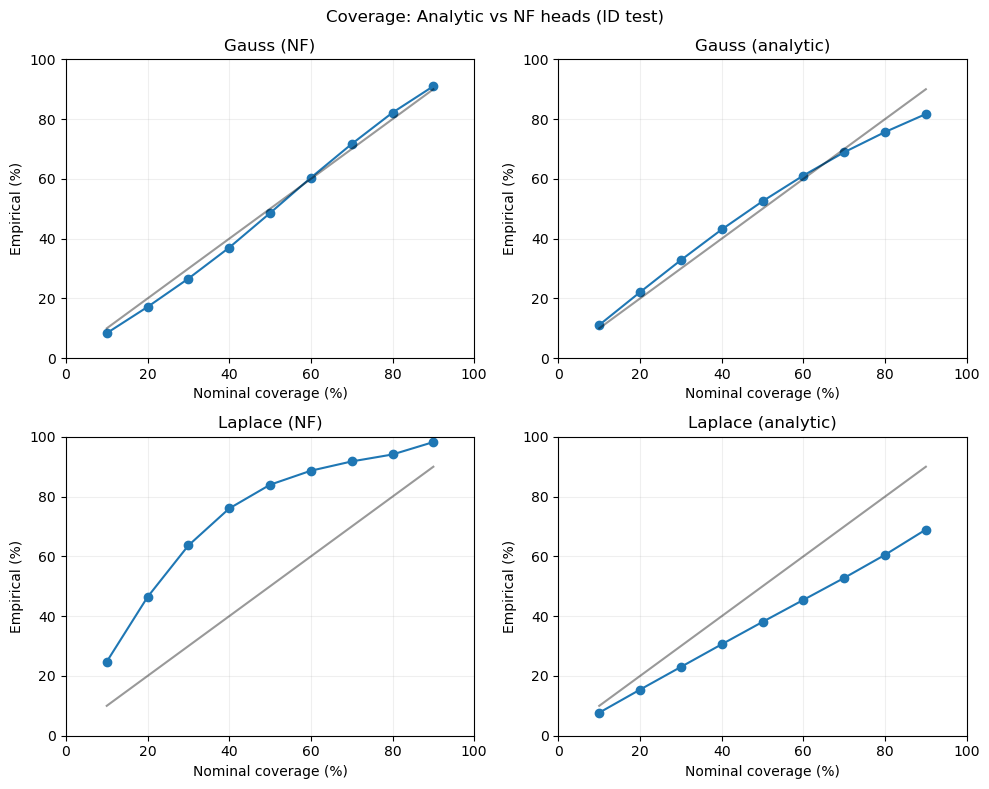

In [27]:
def method_coverage(df, method):
    sub = df[df["method"] == method]
    y = sub["y_true"].to_numpy(float)
    mu = sub["y_pred_mean"].to_numpy(float)
    sigma = sub["sigma_total_orig_cal"].to_numpy(float)
    err = np.abs(y - mu)
    return np.array([np.mean(err <= z_lookup[p] * sigma) for p in nominal])

n_methods = len(methods_nf)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for ax, method in zip(axes, methods_nf):
    cov = method_coverage(df_nf, method) * 100
    ax.plot(nominal * 100, cov, "-o", color="tab:blue")
    ax.plot([10, 90], [10, 90], "k-", alpha=0.4)
    ax.set_title(method)
    ax.set_xlabel("Nominal coverage (%)")
    ax.set_ylabel("Empirical (%)")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.2)
for ax in axes[len(methods_nf):]:
    ax.set_axis_off()
fig.suptitle("Coverage: Analytic vs NF heads (ID test)")
fig.tight_layout()
plt.show()


In [29]:
print("df_nf rows:", len(df_nf), "methods:", methods_nf)


df_nf rows: 1332064 methods: ['Gauss (NF)', 'Gauss (analytic)', 'Laplace (NF)', 'Laplace (analytic)']


Reliability bins rows: (28, 6)


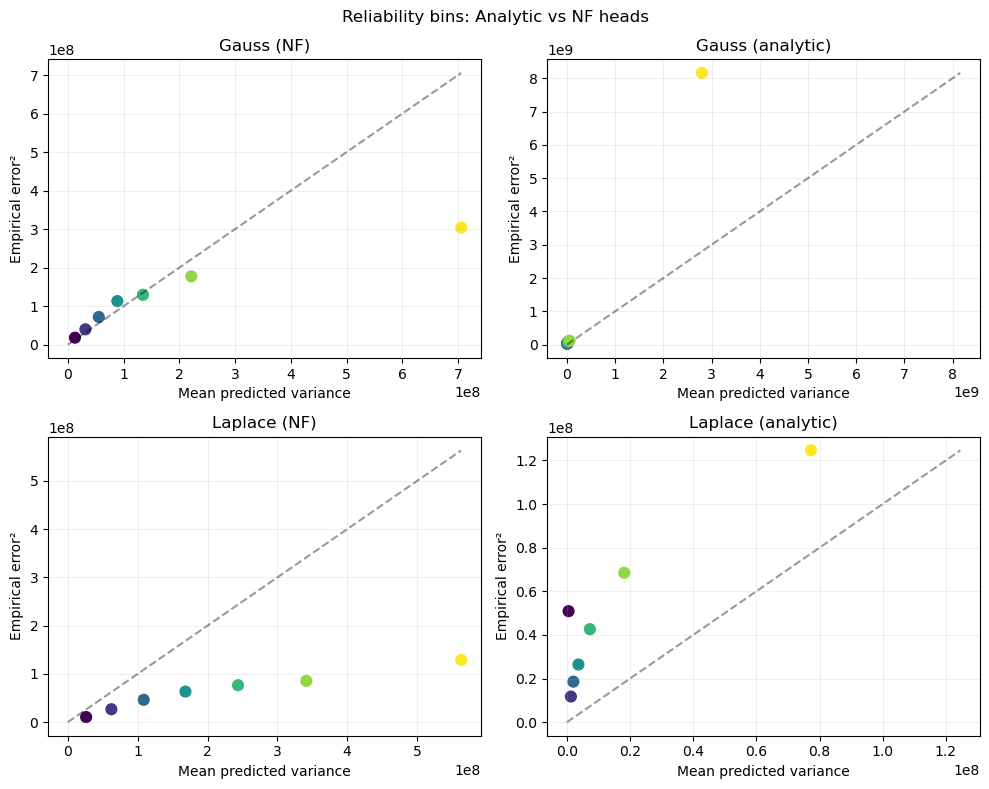

In [30]:
# Reliability bins: Analytic vs NF heads (lighter, no qcut on 1.3M rows)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_bins = 7
rows = []

for method in methods_nf:
    sub = df_nf[df_nf["method"] == method]
    if sub.empty:
        continue

    sigma = sub["sigma_total_orig_cal"].to_numpy(float)
    err2 = (sub["y_true"].to_numpy(float) - sub["y_pred_mean"].to_numpy(float)) ** 2

    mask = np.isfinite(sigma) & np.isfinite(err2)
    sigma = sigma[mask]
    err2 = err2[mask]
    if sigma.size < n_bins:
        continue

    edges = np.quantile(sigma, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if edges.size < 2:
        continue

    bin_ids = np.searchsorted(edges[1:-1], sigma, side="right")

    for b in range(bin_ids.min(), bin_ids.max() + 1):
        idx = bin_ids == b
        if not idx.any():
            continue
        rows.append(
            {
                "method": method,
                "bin": b + 1,
                "bin_sigma_mean": float(sigma[idx].mean()),
                "bin_sigma_var": float((sigma[idx] ** 2).mean()),
                "bin_err2_mean": float(err2[idx].mean()),
                "count": int(idx.sum()),
            }
        )

df_rel_bins = pd.DataFrame(rows)
print("Reliability bins rows:", df_rel_bins.shape)

# Plot aggregated bins
n_methods = len(methods_nf)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, method in zip(axes, methods_nf):
    sub = df_rel_bins[df_rel_bins["method"] == method]
    if sub.empty:
        ax.set_axis_off()
        continue
    pred = sub["bin_sigma_var"]  # variance ~ mean of sigma^2
    err = sub["bin_err2_mean"]
    bin_ids = sub["bin"].to_numpy(float)
    ax.scatter(pred, err, c=bin_ids, cmap="viridis", s=60)
    max_val = max(pred.max(), err.max())
    ax.plot([0, max_val], [0, max_val], "k--", alpha=0.4)
    ax.set_title(method)
    ax.set_xlabel("Mean predicted variance")
    ax.set_ylabel("Empirical error²")
    ax.grid(True, alpha=0.2)

for ax in axes[len(methods_nf):]:
    ax.set_axis_off()

fig.suptitle("Reliability bins: Analytic vs NF heads")
fig.tight_layout()
plt.show()



In [ ]:
STOP

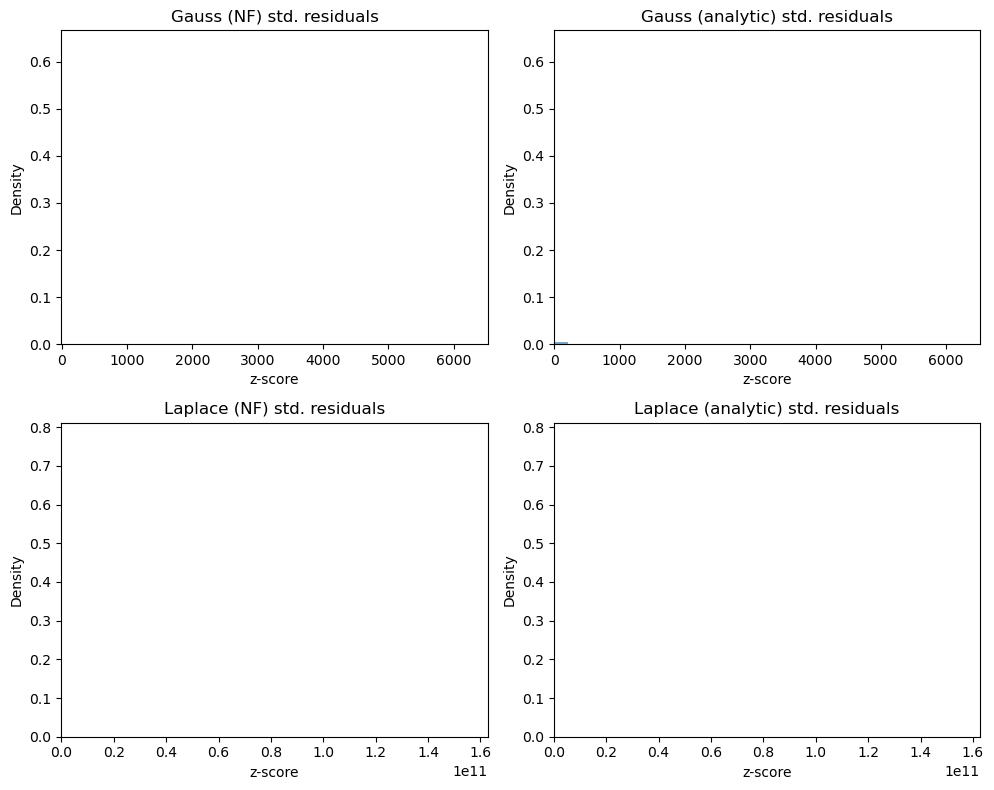

In [31]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

head_limits_hist = {}
hist_data = {}
for method in methods_nf:
    z = ((df_nf[df_nf["method"] == method]["y_true"]
          - df_nf[df_nf["method"] == method]["y_pred_mean"])
         / df_nf[df_nf["method"] == method]["sigma_total_orig_cal"]).to_numpy(float)
    z = z[np.isfinite(z)]
    hist_data[method] = z
    if z.size == 0:
        continue
    xmin, xmax = z.min(), z.max()
    counts, _ = np.histogram(z, bins=30, density=True)
    ymax = counts.max() if counts.size else 0.0
    head = "Gauss" if method.lower().startswith("gauss") else "Laplace"
    if head not in head_limits_hist:
        head_limits_hist[head] = [xmin, xmax, ymax]
    else:
        head_limits_hist[head][0] = min(head_limits_hist[head][0], xmin)
        head_limits_hist[head][1] = max(head_limits_hist[head][1], xmax)
        head_limits_hist[head][2] = max(head_limits_hist[head][2], ymax)

for ax, method in zip(axes, methods_nf):
    z = hist_data.get(method)
    if z is None or z.size == 0:
        ax.set_axis_off()
        continue
    head = "Gauss" if method.lower().startswith("gauss") else "Laplace"
    xmin, xmax, ymax = head_limits_hist.get(head, (0, 0, 0))
    ax.hist(z, bins=30, density=True, alpha=0.7, color="steelblue")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, ymax * 1.05 if ymax > 0 else 1)
    ax.set_title(f"{method} std. residuals")
    ax.set_xlabel("z-score")
    ax.set_ylabel("Density")

for ax in axes[len(methods_nf):]:
    ax.set_axis_off()

fig.tight_layout()
plt.show()


In [ ]:
# Attach original feature columns (including a derived age_bucket) to df_all_cal by merging on row ID.
# Uses the same age_bucket definition as in point_preds_analysis.ipynb:
#   age_years = posting_year - year
#   bins = [-inf, 5, 10, 15, 20, inf]  -> ["0–5", "5–10", "10–15", "15–20", "20+"]

import pandas as pd
import numpy as np
from pathlib import Path

ID_COL = "id"  # change if needed
FEATURES_PATH = PROJECT_ROOT / "datasets" / "craigslist_cleaned_FULL.csv"

# 1) Load only needed columns with dtypes to keep RAM down
feature_usecols = [ID_COL, "manufacturer", "model", "year", "posting_year"]
feature_dtypes = {
    ID_COL: "Int32",
    "year": "Int16",
    "posting_year": "Int16",
    "manufacturer": "category",
    "model": "category",
}

def load_features(path: Path) -> pd.DataFrame:
    if path.suffix == ".parquet":
        return pd.read_parquet(path, columns=feature_usecols)
    else:
        return pd.read_csv(path, usecols=feature_usecols, dtype=feature_dtypes)

# 2) Recreate age_years and age_bucket exactly as in the earlier notebook
df_features = load_features(FEATURES_PATH)

REQUIRED_AGE_COLS = ["year", "posting_year"]
missing_age_cols = [c for c in REQUIRED_AGE_COLS if c not in df_features.columns]
if missing_age_cols:
    raise ValueError(
        f"Missing required columns for age computation in features file: {missing_age_cols}"
    )

df_features["age_years"] = df_features["posting_year"] - df_features["year"]
df_features.loc[df_features["age_years"] < 0, "age_years"] = np.nan
age_bins = [-np.inf, 5, 10, 15, 20, np.inf]
age_labels = ["0–5", "5–10", "10–15", "15–20", "20+"]

df_features["age_bucket"] = pd.cut(
    df_features["age_years"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
)

df_features["age_bucket"] = df_features["age_bucket"].astype("category")

# 3) Select cohort columns and merge into df_all_cal
cohort_cols = [ID_COL, "manufacturer", "model", "age_bucket"]
missing = [c for c in cohort_cols if c not in df_features.columns]
if missing:
    raise ValueError(
        f"These cohort columns are missing from features file after processing: {missing}"
    )

df_feat_cohort = df_features[cohort_cols].copy()

del df_features  # free full features frame before merge

before_cols = set(df_all_cal.columns)
n_before = df_all_cal.shape[0]

df_all_cal = df_all_cal.merge(
    df_feat_cohort,
    on=ID_COL,
    how="left",
    suffixes=("", "_feat"),
)

n_after = df_all_cal.shape[0]
print(f"Merged features on {ID_COL}: rows before={n_before}, after={n_after}")
print(
    "Rows with missing manufacturer after merge:",
    int(df_all_cal["manufacturer"].isna().sum()),
)
print("New columns added:", sorted(set(df_all_cal.columns) - before_cols))

del df_feat_cohort


In [ ]:
# Noise-cohort analysis: analytic vs NF (Laplace/Gauss).
# Cohorts are defined by whichever column trio is available (manufacturer/make, model, age bucket).

import numpy as np
import pandas as pd

# Candidate sets of cohort columns ordered by preference.
COHORT_OPTIONS = [
    ["manufacturer", "model", "age_bucket"],
    ["make", "model", "age_bucket"],
    ["manufacturer", "model", "vehicle_age_bucket"],
    ["make", "model", "vehicle_age_bucket"],
]

cohort_cols = None
for cols in COHORT_OPTIONS:
    if set(cols).issubset(df_all_cal.columns):
        cohort_cols = cols
        break

if cohort_cols is None:
    print(f"[warn] None of the cohort column sets {COHORT_OPTIONS} are present; skipping noise-cohort analysis.")
else:
    cohort_min_size = 100  # configurable threshold

    df_noise = df_all_cal[
        (df_all_cal["split"] == "test")
        & (df_all_cal["head_type"].isin(["laplace", "gauss"]))
        & (df_all_cal["aleatoric_source"].isin(["analytic", "nf"]))
        & (df_all_cal["epistemic_source"] == "none")
    ].copy()

    if df_noise.empty:
        print("[warn] No analytic/NF rows found on test split for noise-cohort analysis.")
    else:
        df_noise["residual"] = df_noise["y_true"] - df_noise["y_pred_mean"]
        df_noise["sigma_ale_sq_cal"] = df_noise["sigma_ale_orig_cal"] ** 2

        cohort_tables = []
        for (head_type, ale_src), sub in df_noise.groupby(["head_type", "aleatoric_source"]):
            tbl = (
                sub.groupby(cohort_cols, observed=True)  # add observed=True here
                .agg(
                    n=("residual", "size"),
                    var_resid=("residual", lambda x: float(np.var(x, ddof=0))),
                    mean_sigma_ale_sq=("sigma_ale_sq_cal", "mean"),
                )
                .reset_index()
            )
            tbl["head_type"] = head_type
            tbl["aleatoric_source"] = ale_src
            cohort_tables.append(tbl)

        if not cohort_tables:
            print("[warn] No cohorts produced; check cohort columns/data.")
        else:
            df_noise_cohorts = pd.concat(cohort_tables, ignore_index=True)
            df_noise_cohorts = (
                df_noise_cohorts[df_noise_cohorts["n"] >= cohort_min_size].reset_index(drop=True)
            )

            if df_noise_cohorts.empty:
                print(f"[warn] No cohorts with at least {cohort_min_size} samples.")
            else:
                noise_summaries = []
                for (head_type, ale_src), sub in df_noise_cohorts.groupby(["head_type", "aleatoric_source"]):
                    corr = sub["var_resid"].corr(sub["mean_sigma_ale_sq"])
                    slope = np.polyfit(sub["mean_sigma_ale_sq"], sub["var_resid"], 1)[0]
                    noise_summaries.append(
                        {
                            "head_type": head_type,
                            "aleatoric_source": ale_src,
                            "n_cohorts": int(sub.shape[0]),
                            "corr(var_resid, E[sigma_a^2])": float(corr),
                            "slope(var_resid ~ E[sigma_a^2])": float(slope),
                            "mean_n_per_cohort": float(sub["n"].mean()),
                        }
                    )

                df_noise_summary = pd.DataFrame(noise_summaries)
                display(df_noise_summary)
                df_noise_cohorts.head()


In [ ]:
# At-a-glance visualization of noise-cohort results:
# each point = one method (head_type + aleatoric_source),
# x = slope(var_resid ~ E[sigma_a^2]), y = correlation,
# size = mean_n_per_cohort.

import matplotlib.pyplot as plt
import numpy as np

if "df_noise_summary" not in globals() or df_noise_summary.empty:
    print("[warn] df_noise_summary is empty; run the noise-cohort cell first.")
else:
    summary = df_noise_summary.copy()
    summary["method"] = (
        summary["head_type"].str.capitalize()
        + " "
        + summary["aleatoric_source"].map({"analytic": "(analytic)", "nf": "(NF)"})
    )

    x = summary["slope(var_resid ~ E[sigma_a^2])"].to_numpy(float)
    y = summary["corr(var_resid, E[sigma_a^2])"].to_numpy(float)
    sizes = summary["mean_n_per_cohort"].to_numpy(float)
    # scale marker sizes for visibility
    sizes_scaled = 20 + 0.1 * sizes

    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(x, y, s=sizes_scaled, alpha=0.8)

    for _, row in summary.iterrows():
        ax.text(
            row["slope(var_resid ~ E[sigma_a^2])"],
            row["corr(var_resid, E[sigma_a^2])"],
            row["method"],
            fontsize=9,
            ha="left",
            va="bottom",
        )

    ax.axvline(1.0, color="gray", linestyle="--", alpha=0.5, label="slope = 1")
    ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5, label="corr = 1")

    ax.set_xlabel("Slope  var(resid)  vs  E[$\\sigma_a^2$]")
    ax.set_ylabel("Correlation  var(resid),  E[$\\sigma_a^2$]")
    ax.set_title("Noise-cohort alignment of aleatoric variance (ID test)")
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


In [ ]:
# Cohort-level log-ratio histograms:
# log_ratio = log(Var(resid) / E[sigma_a^2]) per cohort.
#  - 0    -> perfect match
#  - > 0  -> underestimation (too little aleatoric variance)
#  - < 0  -> overestimation

import numpy as np
import matplotlib.pyplot as plt

if "df_noise_cohorts" not in globals() or df_noise_cohorts.empty:
    print("[warn] df_noise_cohorts is empty; run the noise-cohort analysis cell first.")
else:
    df_ratio = df_noise_cohorts.copy()

    # Avoid division by zero; drop cohorts where mean_sigma_ale_sq is <= 0
    df_ratio = df_ratio[df_ratio["mean_sigma_ale_sq"] > 0].copy()
    if df_ratio.empty:
        print("[warn] No cohorts with positive mean_sigma_ale_sq; cannot compute ratios.")
    else:
        df_ratio["ratio"] = df_ratio["var_resid"] / df_ratio["mean_sigma_ale_sq"]
        df_ratio["log_ratio"] = np.log(df_ratio["ratio"])

        df_ratio["method"] = (
            df_ratio["head_type"].str.capitalize()
            + " "
            + df_ratio["aleatoric_source"].map({"analytic": "(analytic)", "nf": "(NF)"})
        )

        methods = sorted(df_ratio["method"].unique())
        # Separate Gauss and Laplace methods for paired axes
        gauss_methods = [m for m in methods if m.lower().startswith("gauss")]
        laplace_methods = [m for m in methods if m.lower().startswith("laplace")]

        def plot_head_group(method_list, title_prefix):
            if not method_list:
                return

            n = len(method_list)
            ncols = n
            nrows = 1
            fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4), sharey=True)
            if n == 1:
                axes = [axes]

            # Precompute common x-limits for this head type
            all_vals = np.concatenate(
                [df_ratio[df_ratio["method"] == m]["log_ratio"].to_numpy() for m in method_list]
            )
            xmin, xmax = np.percentile(all_vals, [1, 99])  # robust limits
            margin = 0.2 * (xmax - xmin)
            xmin -= margin
            xmax += margin

            for ax, m in zip(axes, method_list):
                vals = df_ratio[df_ratio["method"] == m]["log_ratio"].to_numpy()
                ax.hist(vals, bins=40, density=True, alpha=0.7, color="steelblue")
                ax.axvline(0.0, color="k", linestyle="--", alpha=0.8)  # perfect calibration
                ax.set_xlim(xmin, xmax)
                ax.set_title(m)
                ax.set_xlabel("log Var(resid) – log E[$\\sigma_a^2$]")
                ax.set_ylabel("Density")
                ax.grid(True, alpha=0.2)

            fig.suptitle(f"{title_prefix}: cohort-level log variance ratio", y=1.02)
            plt.tight_layout()
            plt.show()

        plot_head_group(gauss_methods, "Gauss")
        plot_head_group(laplace_methods, "Laplace")


In [ ]:
# Large-error detection metrics on ID-test (core methods + DIDO).
# - Uses LARGE_ERROR_TAU (from point baseline) to define large_error.
# - For each core method, computes AUROC / AUPRC for U_a, U_e, U_total.
# - For DIDO methods, also computes AUROC / AUPRC for the DIDO score
#   (calibrated P_large_error if present, otherwise vacuity/entropy).

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# 1) Build large_error indicator on ID test
if LARGE_ERROR_TAU is None:
    raise ValueError("LARGE_ERROR_TAU is None; run the threshold-computation cell first.")

df_test_le = df_all_cal[df_all_cal["split"] == "test"].copy()
df_test_le["abs_error"] = (df_test_le["y_true"] - df_test_le["y_pred_mean"]).abs()
df_test_le["large_error"] = (df_test_le["abs_error"] >= LARGE_ERROR_TAU).astype(int)

def auroc_auprc(y_true: np.ndarray, scores: np.ndarray):
    """Return (AUROC, AUPRC) for given labels and scores, or (nan, nan) if degenerate."""
    mask = np.isfinite(scores)
    y = y_true[mask].astype(int)
    s = scores[mask].astype(float)
    if y.size == 0 or np.unique(y).size < 2:
        return np.nan, np.nan
    return roc_auc_score(y, s), average_precision_score(y, s)

# 2) Core methods (same set as in core metrics section) + DIDO
core_methods = [
    ("point",   "none",     "none",     "Point baseline"),
    ("laplace", "analytic", "none",     "Laplace (analytic)"),
    ("laplace", "analytic", "mc",       "Laplace + MC"),
    ("laplace", "analytic", "ensemble", "Laplace + ensemble"),
    ("laplace", "analytic", "dido",     "Laplace + DIDO"),
    ("gauss",   "analytic", "none",     "Gauss (analytic)"),
    ("gauss",   "analytic", "mc",       "Gauss + MC"),
    ("gauss",   "analytic", "ensemble", "Gauss + ensemble"),
    ("gauss",   "analytic", "dido",     "Gauss + DIDO"),
]

def find_dido_score_column(sub: pd.DataFrame) -> tuple[str | None, str]:
    """
    Try to find the best DIDO score column in `sub`:
      1) calibrated probability of large error (name contains both 'dido' and 'large')
      2) vacuity
      3) entropy
    Returns (column_name or None, descriptor).
    """
    cols = [c.lower() for c in sub.columns]

    # Calibrated probability (preferred)
    for c in sub.columns:
        cl = c.lower()
        if "dido" in cl and "large" in cl:
            return c, "dido_prob"

    # Vacuity
    for c in sub.columns:
        cl = c.lower()
        if "vacuity" in cl and "dido" in cl:
            return c, "dido_vacuity"

    # Entropy
    for c in sub.columns:
        cl = c.lower()
        if "entropy" in cl and "dido" in cl:
            return c, "dido_entropy"

    return None, ""

rows = []
for head_type, ale_src, epi_src, label in core_methods:
    sub = df_test_le[
        (df_test_le["head_type"] == head_type)
        & (df_test_le["aleatoric_source"] == ale_src)
        & (df_test_le["epistemic_source"] == epi_src)
    ].copy()
    if sub.empty:
        continue

    y = sub["large_error"].to_numpy(int)

    # Aleatoric, epistemic, total (where available)
    score_specs = [
        ("sigma_ale_orig_cal",   "U_a"),
        ("sigma_epi_orig_cal",   "U_e"),
        ("sigma_total_orig_cal", "U_total"),
    ]

    for col, score_type in score_specs:
        if col not in sub.columns:
            continue
        if sub[col].notna().sum() == 0:
            continue
        auroc, auprc = auroc_auprc(y, sub[col].to_numpy(float))
        rows.append(
            {
                "head_type": head_type,
                "aleatoric_source": ale_src,
                "epistemic_source": epi_src,
                "method": label,
                "score_type": score_type,
                "score_column": col,
                "n": int(sub.shape[0]),
                "auroc": float(auroc) if auroc == auroc else np.nan,
                "auprc": float(auprc) if auprc == auprc else np.nan,
            }
        )

    # DIDO-specific score (if this is a DIDO method)
    if epi_src == "dido":
        dido_col, dido_desc = find_dido_score_column(sub)
        if dido_col is not None:
            auroc, auprc = auroc_auprc(y, sub[dido_col].to_numpy(float))
            rows.append(
                {
                    "head_type": head_type,
                    "aleatoric_source": ale_src,
                    "epistemic_source": epi_src,
                    "method": label,
                    "score_type": dido_desc,
                    "score_column": dido_col,
                    "n": int(sub.shape[0]),
                    "auroc": float(auroc) if auroc == auroc else np.nan,
                    "auprc": float(auprc) if auprc == auprc else np.nan,
                }
            )

df_large_error_metrics = pd.DataFrame(rows).sort_values(
    ["method", "score_type"]
).reset_index(drop=True)

display(df_large_error_metrics)


In [ ]:
# DIDO-specific diagnostics on ID test:
#  - Reliability curve of DIDO score (predicted vs empirical large-error rate)
#  - Simple AUROC/AUPRC comparison vs MC / ensemble (from df_large_error_metrics)
#  - Histogram of DIDO scores for ID vs OOD (if OOD data is present)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

# Helper to locate the main DIDO score column
def find_dido_score_column(columns):
    """
    Pick the most informative DIDO score column from a list of column names:
      1) calibrated probability of large error (contains 'dido' and 'large')
      2) vacuity (contains 'dido' and 'vacuity')
      3) entropy (contains 'dido' and 'entropy')
    Returns column name or None.
    """
    lower = [c.lower() for c in columns]

    # 1) calibrated probability
    for c in columns:
        cl = c.lower()
        if "dido" in cl and "large" in cl:
            return c

    # 2) vacuity
    for c in columns:
        cl = c.lower()
        if "dido" in cl and "vacuity" in cl:
            return c

    # 3) entropy
    for c in columns:
        cl = c.lower()
        if "dido" in cl and "entropy" in cl:
            return c

    return None

if LARGE_ERROR_TAU is None:
    print("[warn] LARGE_ERROR_TAU is None; run the large-error threshold cell first.")
else:
    # 1) Prepare DIDO subset on ID test
    df_dido_test = df_all_cal[
        (df_all_cal["split"] == "test")
        & (df_all_cal["epistemic_source"] == "dido")
    ].copy()

    if df_dido_test.empty:
        print("[warn] No DIDO rows on test split; skipping DIDO diagnostics.")
    else:
        df_dido_test["abs_error"] = (df_dido_test["y_true"] - df_dido_test["y_pred_mean"]).abs()
        df_dido_test["large_error"] = (df_dido_test["abs_error"] >= LARGE_ERROR_TAU).astype(int)

        dido_col = find_dido_score_column(df_dido_test.columns)
        if dido_col is None:
            print("[warn] No DIDO score column (prob/vacuity/entropy) found; skipping DIDO diagnostics.")
        else:
            print(f"Using DIDO score column: {dido_col}")

            # Drop NaNs for reliability and metrics
            df_dido_score = df_dido_test[[dido_col, "large_error"]].dropna()
            scores = df_dido_score[dido_col].to_numpy(float)
            labels = df_dido_score["large_error"].to_numpy(int)

            # 2) Reliability curve: predicted vs empirical large-error rate
            n_bins = 10
            df_rel = df_dido_score.copy()
            df_rel["bin"] = pd.qcut(
                df_rel[dido_col],
                q=n_bins,
                labels=False,
                duplicates="drop",
            )
            grouped = df_rel.groupby("bin", observed=True)
            rel_tbl = grouped.agg(
                pred_mean=(dido_col, "mean"),
                emp_large_error=("large_error", "mean"),
                n=("large_error", "size"),
            ).reset_index()

            fig, ax = plt.subplots(figsize=(6, 5))
            ax.plot(rel_tbl["pred_mean"], rel_tbl["emp_large_error"], "-o", color="tab:blue")
            ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xlabel("Mean predicted DIDO score")
            ax.set_ylabel("Empirical large-error rate")
            ax.set_title("DIDO reliability curve (ID test)")
            ax.grid(True, alpha=0.2)
            plt.tight_layout()
            plt.show()

            # 3) AUROC / AUPRC for DIDO vs MC / ensemble, using df_large_error_metrics
            if "df_large_error_metrics" in globals() and not df_large_error_metrics.empty:
                cmp_scores = ["U_e", "U_total", "U_a", "dido_prob", "dido_vacuity", "dido_entropy"]
                cmp = df_large_error_metrics[
                    df_large_error_metrics["score_type"].isin(cmp_scores)
                ].copy()

                # Focus on Laplace / Gauss methods with and without DIDO
                display_cols = [
                    "method",
                    "score_type",
                    "auroc",
                    "auprc",
                ]
                print("Large-error AUROC/AUPRC for DIDO vs MC/ensemble (where available):")
                display(cmp[display_cols].sort_values(["method", "score_type"]))

            else:
                print("[warn] df_large_error_metrics not available; skipping numeric comparison table.")

            # 4) Histogram of DIDO scores: ID vs OOD (if OOD present)
            if "dataset" in df_dido_test.columns and df_dido_test["dataset"].nunique() > 1:
                # Treat the majority dataset in test as ID, others as OOD
                counts = df_dido_test["dataset"].value_counts()
                id_label = counts.idxmax()
                id_scores = df_dido_test.loc[df_dido_test["dataset"] == id_label, dido_col].dropna()
                ood_scores = df_dido_test.loc[df_dido_test["dataset"] != id_label, dido_col].dropna()

                fig, ax = plt.subplots(figsize=(6, 4))
                ax.hist(id_scores, bins=40, density=True, alpha=0.6, label=f"ID ({id_label})")
                if not ood_scores.empty:
                    ax.hist(ood_scores, bins=40, density=True, alpha=0.6, label="OOD (all others)")
                ax.set_xlabel(f"DIDO score ({dido_col})")
                ax.set_ylabel("Density")
                ax.set_title("DIDO score distribution: ID vs OOD (test)")
                ax.legend()
                ax.grid(True, alpha=0.2)
                plt.tight_layout()
                plt.show()
            else:
                print("[info] No OOD dataset labels on test (or only one dataset); skipping ID vs OOD DIDO histogram.")


In [ ]:
# Visualizations for large-error detection metrics (df_large_error_metrics).
# - Per-method bar plots for AUROC and AUPRC across score types (U_a, U_e, U_total, DIDO).
# - Global AUROC vs AUPRC scatter, colored by score_type and shaped by head_type.

import numpy as np
import matplotlib.pyplot as plt

if "df_large_error_metrics" not in globals() or df_large_error_metrics.empty:
    print("[warn] df_large_error_metrics is empty; run the large-error metrics cell first.")
else:
    metrics = df_large_error_metrics.copy()

    # Consistent ordering for score types where present
    score_type_order = [
        "U_total",
        "U_e",
        "U_a",
        "dido_prob",
        "dido_vacuity",
        "dido_entropy",
    ]

    # ----------------------------
    # 1) Per-method AUROC bar plots
    # ----------------------------
    methods = sorted(metrics["method"].unique())
    n_methods = len(methods)
    ncols = 3
    nrows = int(np.ceil(n_methods / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharey=True)
    axes = axes.flatten()

    for ax, method in zip(axes, methods):
        sub = metrics[metrics["method"] == method].copy()
        if sub.empty:
            ax.set_axis_off()
            continue
        # Order score types
        stypes = [s for s in score_type_order if s in sub["score_type"].unique()]
        sub = sub.set_index("score_type").loc[stypes].reset_index()

        x = np.arange(len(stypes))
        ax.bar(x, sub["auroc"].to_numpy(float), color="tab:blue", alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(stypes, rotation=45, ha="right")
        ax.set_ylim(0.0, 1.0)
        ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)  # random baseline
        ax.set_title(method)
        ax.set_ylabel("AUROC")

    for ax in axes[len(methods):]:
        ax.set_axis_off()

    fig.suptitle("Large-error detection AUROC by method and score type", y=1.02)
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # 2) Per-method AUPRC bar plots
    # ----------------------------
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharey=True)
    axes = axes.flatten()

    for ax, method in zip(axes, methods):
        sub = metrics[metrics["method"] == method].copy()
        if sub.empty:
            ax.set_axis_off()
            continue
        stypes = [s for s in score_type_order if s in sub["score_type"].unique()]
        sub = sub.set_index("score_type").loc[stypes].reset_index()

        x = np.arange(len(stypes))
        ax.bar(x, sub["auprc"].to_numpy(float), color="tab:orange", alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(stypes, rotation=45, ha="right")
        ax.set_ylim(0.0, 1.0)
        # random baseline ~ prevalence; approximate by mean of large_error
        ax.set_title(method)
        ax.set_ylabel("AUPRC")

    for ax in axes[len(methods):]:
        ax.set_axis_off()

    fig.suptitle("Large-error detection AUPRC by method and score type", y=1.02)
    plt.tight_layout()
    plt.show()

    # ---------------------------------
    # 3) AUROC vs AUPRC scatter summary
    # ---------------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    # Color by score_type
    unique_scores = metrics["score_type"].unique()
    cmap = plt.get_cmap("tab10")
    color_map = {s: cmap(i % 10) for i, s in enumerate(sorted(unique_scores))}

    # Marker by head_type
    marker_map = {"point": "x", "laplace": "o", "gauss": "s"}
    default_marker = "."

    for _, row in metrics.iterrows():
        stype = row["score_type"]
        color = color_map.get(stype, "gray")
        htype = row["head_type"]
        marker = marker_map.get(htype, default_marker)

        ax.scatter(
            row["auroc"],
            row["auprc"],
            color=color,
            marker=marker,
            s=60,
            alpha=0.8,
        )

    # Reference random baseline for AUROC
    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.4)

    ax.set_xlabel("AUROC (large-error detection)")
    ax.set_ylabel("AUPRC (large-error detection)")
    ax.set_title("Summary: AUROC vs AUPRC by method and score type")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.2)

    # Legends
    from matplotlib.lines import Line2D

    score_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=color_map[s], label=s)
        for s in sorted(unique_scores)
    ]
    head_handles = [
        Line2D([0], [0], marker=m, linestyle="", color="black", label=ht)
        for ht, m in marker_map.items()
    ]

    legend1 = ax.legend(
        handles=score_handles, title="Score type", loc="lower left", bbox_to_anchor=(1.02, 0.0)
    )
    ax.add_artist(legend1)
    ax.legend(
        handles=head_handles, title="Head type", loc="upper left", bbox_to_anchor=(1.02, 1.0)
    )

    plt.tight_layout()
    plt.show()


In [ ]:
sub = df_test_le[
    (df_test_le["head_type"] == "laplace") &
    (df_test_le["aleatoric_source"] == "analytic") &
    (df_test_le["epistemic_source"] == "dido")
]
print("large_error counts:", sub["large_error"].value_counts(dropna=False))
print("finite vacuity:", np.isfinite(sub["dido_vacuity_raw"]).sum())


In [ ]:
print("Global mean large_error:", df_test_le["large_error"].mean())
print("τ (point baseline):", LARGE_ERROR_TAU)
print("DIDO abs_error quantiles:", df_dido_test["abs_error"].quantile([0.9, 0.95, 0.99]))


In [ ]:
df_dido_test = df_all_cal[
    (df_all_cal["split"] == "test") & (df_all_cal["epistemic_source"] == "dido")
].copy()

print(df_dido_test[["y_true", "y_pred_mean"]].isna().sum())


In [ ]:
# Data-size experiment: effect of train_frac on Laplace + MC (and any other methods
# that have multiple train_frac values). Handles the case where no such variants exist.

import numpy as np
import pandas as pd

from scipy.stats import norm

# Helper: Gaussian CRPS for vectors, averaged over samples
def gaussian_crps_mean(y, mu, sigma):
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return np.nan
    y = y[mask]
    mu = mu[mask]
    sigma = sigma[mask]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))

# We’ll work on ID test split only
df_test_size = df_all_cal[df_all_cal["split"] == "test"].copy()

if "train_frac" not in df_test_size.columns:
    print("[info] No train_frac column in df_all_cal; skipping data-size experiment.")
    df_data_size = pd.DataFrame()
else:
    rows = []

    # Focus on Laplace + MC first, but allow any method that has >1 train_frac
    for (head_type, ale_src, epi_src), sub_all in df_test_size.groupby(
        ["head_type", "aleatoric_source", "epistemic_source"]
    ):
        # Only keep methods with multiple train_frac values
        fracs = sorted(sub_all["train_frac"].dropna().unique().tolist())
        if len(fracs) <= 1:
            continue

        for frac in fracs:
            sub = sub_all[sub_all["train_frac"] == frac].copy()
            if sub.empty:
                continue

            y = sub["y_true"].to_numpy(float)
            mu = sub["y_pred_mean"].to_numpy(float)

            mae = float(np.mean(np.abs(y - mu)))
            rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
            crps = gaussian_crps_mean(
                y, mu, sub["sigma_total_orig_cal"].to_numpy(float)
            )

            mean_u_a = float(sub["sigma_ale_orig_cal"].mean())
            mean_u_e = float(sub["sigma_epi_orig_cal"].mean())

            # Large-error metrics, if available
            auroc_u_a = auprc_u_a = np.nan
            auroc_u_e = auprc_u_e = np.nan
            auroc_u_tot = auprc_u_tot = np.nan

            if "large_error" in sub.columns and "auroc_auprc" in globals():
                y_bin = sub["large_error"].to_numpy(int)

                for col, label in [
                    ("sigma_ale_orig_cal", "U_a"),
                    ("sigma_epi_orig_cal", "U_e"),
                    ("sigma_total_orig_cal", "U_total"),
                ]:
                    scores = sub[col].to_numpy(float)
                    auroc, auprc = auroc_auprc(y_bin, scores)
                    if label == "U_a":
                        auroc_u_a, auprc_u_a = auroc, auprc
                    elif label == "U_e":
                        auroc_u_e, auprc_u_e = auroc, auprc
                    else:
                        auroc_u_tot, auprc_u_tot = auroc, auprc

            rows.append(
                {
                    "head_type": head_type,
                    "aleatoric_source": ale_src,
                    "epistemic_source": epi_src,
                    "train_frac": float(frac),
                    "n": int(sub.shape[0]),
                    "MAE": mae,
                    "RMSE": rmse,
                    "CRPS": crps,
                    "mean_U_a": mean_u_a,
                    "mean_U_e": mean_u_e,
                    "AUROC_U_a": auroc_u_a,
                    "AUPRC_U_a": auprc_u_a,
                    "AUROC_U_e": auroc_u_e,
                    "AUPRC_U_e": auprc_u_e,
                    "AUROC_U_total": auroc_u_tot,
                    "AUPRC_U_total": auprc_u_tot,
                }
            )

    if not rows:
        print(
            "[info] No methods with multiple train_frac values found on test; "
            "df_data_size will be empty."
        )
        df_data_size = pd.DataFrame()
    else:
        df_data_size = pd.DataFrame(rows).sort_values(
            ["head_type", "aleatoric_source", "epistemic_source", "train_frac"]
        )
        display(df_data_size.head())


In [ ]:
# OOD metrics on ID-test vs OOD-test datasets.
# - Requires a 'dataset' column in df_all_cal and a defined ID label (settings.dataset).
# - Computes, per method and OOD dataset:
#     * OOD-only MAE, RMSE, CRPS, NLL, mean U_a/U_e/U_total
#     * OOD-detection AUROC/AUPRC using U_a, U_e, U_total, and DIDO score (if present).

import numpy as np
import pandas as pd
from scipy.stats import norm
from scripts.uq_eval import gaussian_nll

# CRPS helper (reuse if already defined)
if "gaussian_crps_mean" not in globals():
    def gaussian_crps_mean(y, mu, sigma):
        y = np.asarray(y, float)
        mu = np.asarray(mu, float)
        sigma = np.asarray(sigma, float)
        mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
        if not np.any(mask):
            return np.nan
        y = y[mask]
        mu = mu[mask]
        sigma = sigma[mask]
        z = (y - mu) / sigma
        crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
        return float(np.mean(crps))

# DIDO score locator (reuse if already defined)
if "find_dido_score_column" not in globals():
    def find_dido_score_column(columns):
        cols = list(columns)
        for c in cols:
            cl = c.lower()
            if "dido" in cl and "large" in cl:
                return c, "dido_prob"
        for c in cols:
            cl = c.lower()
            if "dido" in cl and "vacuity" in cl:
                return c, "dido_vacuity"
        for c in cols:
            cl = c.lower()
            if "dido" in cl and "entropy" in cl:
                return c, "dido_entropy"
        return None, ""

if "dataset" not in df_all_cal.columns:
    print("[info] df_all_cal has no 'dataset' column; skipping OOD metrics.")
    df_ood_metrics = pd.DataFrame()
else:
    id_label = getattr(settings, "dataset", "id")

    primary_ood = ["geo", "rare_manu", "tail_multi"]
    secondary_ood = ["mpy", "odo", "year_old"]

    available = sorted(df_all_cal["dataset"].unique().tolist())
    print("Available dataset labels:", available)

    primary_used = [d for d in primary_ood if d in available]
    secondary_used = [d for d in secondary_ood if d in available]

    if not primary_used and not secondary_used:
        print("[info] No configured OOD datasets present; df_ood_metrics will be empty.")
        df_ood_metrics = pd.DataFrame()
    else:
        rows = []
        df_test_all = df_all_cal[df_all_cal["split"] == "test"].copy()
        df_test_id = df_test_all[df_test_all["dataset"] == id_label].copy()

        def ood_loop(ood_list, ood_type):
            for ood_ds in ood_list:
                df_test_ood = df_test_all[df_test_all["dataset"] == ood_ds].copy()
                if df_test_ood.empty:
                    continue

                for (head_type, ale_src, epi_src), sub_ood in df_test_ood.groupby(
                    ["head_type", "aleatoric_source", "epistemic_source"]
                ):
                    sub_id = df_test_id[
                        (df_test_id["head_type"] == head_type)
                        & (df_test_id["aleatoric_source"] == ale_src)
                        & (df_test_id["epistemic_source"] == epi_src)
                    ]
                    if sub_id.empty or sub_ood.empty:
                        continue

                    # OOD-only performance
                    y = sub_ood["y_true"].to_numpy(float)
                    mu = sub_ood["y_pred_mean"].to_numpy(float)
                    mae = float(np.mean(np.abs(y - mu)))
                    rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
                    crps = gaussian_crps_mean(
                        y, mu, sub_ood["sigma_total_orig_cal"].to_numpy(float)
                    )

                    sigma = sub_ood["sigma_total_orig_cal"].to_numpy(float)
                    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
                    if np.any(mask):
                        nll = float(gaussian_nll(y[mask], mu[mask], sigma[mask]))
                    else:
                        nll = np.nan

                    mean_u_a = float(sub_ood["sigma_ale_orig_cal"].mean())
                    mean_u_e = float(sub_ood["sigma_epi_orig_cal"].mean())
                    mean_u_tot = float(sub_ood["sigma_total_orig_cal"].mean())

                    # OOD detection: ID vs this OOD
                    auroc_u_a = auprc_u_a = np.nan
                    auroc_u_e = auprc_u_e = np.nan
                    auroc_u_tot = auprc_u_tot = np.nan
                    auroc_dido = auprc_dido = np.nan
                    dido_score_type = ""

                    if "auroc_auprc" in globals():
                        df_comb = pd.concat([sub_id, sub_ood], ignore_index=True)
                        y_ood = (df_comb["dataset"] == ood_ds).astype(int).to_numpy(int)

                        for col, label in [
                            ("sigma_ale_orig_cal", "U_a"),
                            ("sigma_epi_orig_cal", "U_e"),
                            ("sigma_total_orig_cal", "U_total"),
                        ]:
                            scores = df_comb[col].to_numpy(float)
                            auroc, auprc = auroc_auprc(y_ood, scores)
                            if label == "U_a":
                                auroc_u_a, auprc_u_a = auroc, auprc
                            elif label == "U_e":
                                auroc_u_e, auprc_u_e = auroc, auprc
                            else:
                                auroc_u_tot, auprc_u_tot = auroc, auprc

                        if epi_src == "dido":
                            dido_col, dido_desc = find_dido_score_column(df_comb.columns)
                            if dido_col is not None:
                                s = df_comb[dido_col].to_numpy(float)
                                auroc_dido, auprc_dido = auroc_auprc(y_ood, s)
                                dido_score_type = dido_desc

                    rows.append(
                        {
                            "ood_type": ood_type,
                            "ood_dataset": ood_ds,
                            "head_type": head_type,
                            "aleatoric_source": ale_src,
                            "epistemic_source": epi_src,
                            "n_id": int(sub_id.shape[0]),
                            "n_ood": int(sub_ood.shape[0]),
                            "MAE_ood": mae,
                            "RMSE_ood": rmse,
                            "CRPS_ood": crps,
                            "NLL_ood": nll,
                            "mean_U_a_ood": mean_u_a,
                            "mean_U_e_ood": mean_u_e,
                            "mean_U_total_ood": mean_u_tot,
                            "AUROC_U_a_ood": auroc_u_a,
                            "AUPRC_U_a_ood": auprc_u_a,
                            "AUROC_U_e_ood": auroc_u_e,
                            "AUPRC_U_e_ood": auprc_u_e,
                            "AUROC_U_total_ood": auroc_u_tot,
                            "AUPRC_U_total_ood": auprc_u_tot,
                            "DIDO_score_type": dido_score_type,
                            "AUROC_DIDO_ood": auroc_dido,
                            "AUPRC_DIDO_ood": auprc_dido,
                        }
                    )

        ood_loop(primary_used, "primary")
        ood_loop(secondary_used, "secondary")

        if not rows:
            print("[info] No OOD metrics could be computed (no overlapping methods).")
            df_ood_metrics = pd.DataFrame()
        else:
            df_ood_metrics = pd.DataFrame(rows).sort_values(
                ["ood_type", "ood_dataset", "head_type", "aleatoric_source", "epistemic_source"]
            )
            display(df_ood_metrics.head())
